# **Project** 1

### How well can you predict which brain region a neuron is in based on its activity?

This dataset surveyed visual responses across six different visual areas. One of the key questions we can ask is how the neural responses differ across these areas? There have been several studies that have looked at this, both using these data as well as other data. Two papers that motivated this study were published back-to-back: [Marshel, Garrett et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01046-4?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010464%3Fshowall%3Dtrue) and [Andermann et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01012-9?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010129%3Fshowall%3Dtrue). These two studies compared the tuning properties of neurons in different areas in the mouse visual cortex. They compared area responses using metrics such as orientation selectivity, preferred temporal frequency (TF), and preferred spatial frequency (SF).  Andermann et al particularly focused on the differences between areas AL and PM as these are thought to be parts of the ventral and dorsal visual streams, respectively. [see lecture slides X-Y]

Another notable study, [Kumar et al 2021](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008548), uses the Allen Brain Observatory data to show that neurons can be parcellated into brain regions using short segments of natural movie responses or even spontaneous activity.

The question here is how accurately can you classify neurons into their respective brain regions based on their responses to the drifting grating stimulus?


In [2]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix

Set up the AllenSDK and point it to the data manifest

In [3]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [4]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

Get a dataframe of sessions in VISpm, layer 2/3 Cux2 when drifting gratings were shown

In [5]:
exps_pm = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

Look at the data frame. How long is it?

In [6]:
exps_pm.head()

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,504115289,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),124,511510817,three_session_A,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True
1,502666254,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),96,511510645,three_session_A,225039,Cux2-CreERT2;Camk2a-tTA;Ai93-225039,True
2,658854537,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),110,658854535,three_session_A,360566,Cux2-CreERT2;Camk2a-tTA;Ai93-360566,False
3,512311673,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),91,511976252,three_session_A,233214,Cux2-CreERT2;Camk2a-tTA;Ai93-233214,True
4,510859641,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),82,511511083,three_session_A,233215,Cux2-CreERT2;Camk2a-tTA;Ai93-233215,False


In [7]:
len(exps_pm)

9

Now repeat this to get a dataframe of sessions in VISal, layer 2/3 Cux2 when drifting gratings were shown

In [8]:
exps_al = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

In [9]:
len(exps_al)

6

In tutorial 2 we wrote a function to compute the tuning curves for all the neurons in a single session. Copy and paste that here:

In [10]:
def compute_tuning(session_id):
    """
    Computes the 2D tuning array for all neurons in a given session
    for drifting gratings stimulus.

    Parameters
    ----------
    session_id : int
        The session id for one session.

    Returns
    -------
    dff : numpy.ndarray
        Delta F over F traces for all cells.
    stim_table : pandas.DataFrame
        Stimulus table for drifting gratings.
    trial_response : pandas.DataFrame
        Response per trial for all neurons.
    tuning_array : numpy.ndarray
        2D tuning array for all neurons, with dimensions (orientation, temporal_frequency, cell index).
    """
    #access data for the session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for all cells
    timestamps, dff = data_set.get_dff_traces()
    number_cells = dff.shape[0]
    print("Number of cells: ", number_cells)

    #get the stimulus table for the drifting gratings
    stim_table = data_set.get_stimulus_table('drifting_gratings')

    #get the orivals and tfvals
    all_ori = np.unique(stim_table.orientation)
    orivals = all_ori[np.isfinite(all_ori)]
    tfvals = np.unique(stim_table.temporal_frequency)
    tfvals = tfvals[np.isfinite(tfvals)]

    #compute response per trial for all neurons
    trial_response = pd.DataFrame(index=stim_table.index.values, columns=np.array(range(number_cells)).astype(str))

    for ind,row in stim_table.iterrows():
        for nc in range(number_cells):
            trial_response.loc[ind, str(nc)] = dff[nc,int(row.start):int(row.end)].mean()

    #calculate the response to the blanksweeps:
    blank_response = trial_response[np.isnan(stim_table.orientation)].mean()

    #compute 2D tuning array and subtract the blanksweep response
    tuning_array = np.empty((8,5,number_cells))
    for i,tf in enumerate(tfvals): #iterate across TF
        for j,ori in enumerate(orivals): #iterate across ori
            tuning_array[j,i,:] = trial_response[(stim_table.orientation==ori)&
                                                 (stim_table.temporal_frequency==tf)].mean() - blank_response

    return(dff, stim_table, trial_response, tuning_array)

Let's test this on the first session in our exps_pm list

In [11]:
session_id = exps_pm.id[0]
(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)
print("example session:", session_id)
print("dff            :", dff.shape, "= (n_cells, n_timepoints)  raw calcium traces")
print("stim_table     :", stim_table.shape, "= (n_presentations, columns)  what/when was shown")
print("trial_response :", trial_response.shape, "= (n_trials, n_cells)  one response per trial per cell")
print("tuning_array   :", tuning_array.shape, "= (8 ori, 5 TF, n_cells)  trial-averaged tuning")

Number of cells:  94
example session: 504115289
dff            : (94, 115470) = (n_cells, n_timepoints)  raw calcium traces
stim_table     : (628, 5) = (n_presentations, columns)  what/when was shown
trial_response : (628, 94) = (n_trials, n_cells)  one response per trial per cell
tuning_array   : (8, 5, 94) = (8 ori, 5 TF, n_cells)  trial-averaged tuning


**(a) `dff` - the raw signal.** This is fluorescence over time for every neuron: the closest thing to "what the microscope saw". Bumps are calcium events (roughly, spiking). Everything else is derived from this.

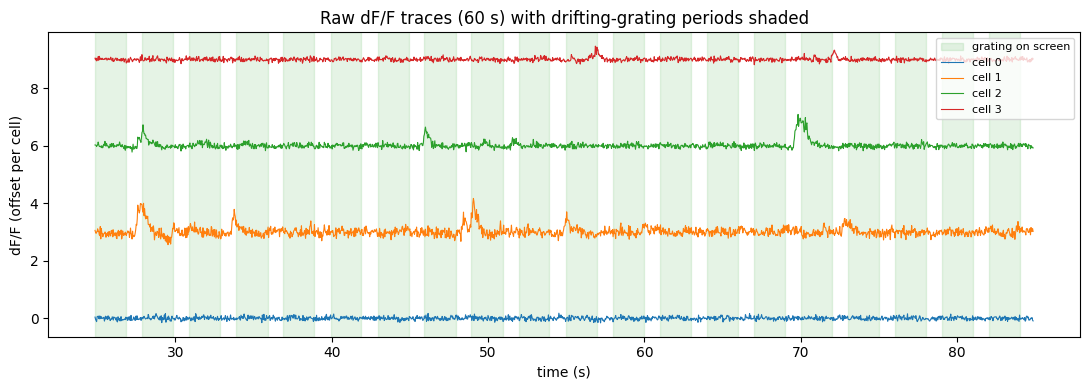

In [12]:
# plot a 60 s window of a few example neurons (assume ~30 Hz imaging).
# start the window at the first drifting-grating presentation so the stimulus is visible.
fs = 30
t = np.arange(dff.shape[1]) / fs
t0_win = stim_table.start.min() / fs        # first grating presentation (in seconds)
t1_win = t0_win + 60
window = (t >= t0_win) & (t < t1_win)

plt.figure(figsize=(11, 4))

# shade each interval when a grating is ON screen (blank/grey-screen gaps stay unshaded)
first = True
for _, row in stim_table.iterrows():
    a, b = row.start / fs, row.end / fs
    if b < t0_win or a > t1_win or not np.isfinite(row.orientation):
        continue
    plt.axvspan(max(a, t0_win), min(b, t1_win), color="tab:green", alpha=0.12,
                label="grating on screen" if first else None)
    first = False

for k, cell in enumerate([0, 1, 2, 3]):
    plt.plot(t[window], dff[cell, window] + k * 3, lw=0.8, label=f"cell {cell}")
plt.xlabel("time (s)"); plt.ylabel("dF/F (offset per cell)")
plt.title("Raw dF/F traces (60 s) with drifting-grating periods shaded")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

Text(0, 0.5, 'mean dF/F')

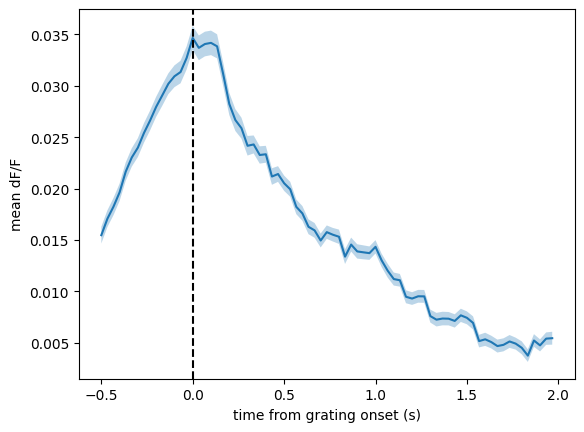

In [13]:
fs = 30
pre  = int(0.5 * fs)      # 0.5 s baseline before onset
win  = int(2.5 * fs)      # 0.5 s pre + 2 s stimulus

snips = []
for _, row in stim_table.iterrows():
    if not np.isfinite(row.orientation):          # gratings only (skip blanks)
        continue
    s = int(row.start) - pre
    seg = dff[:, s:s+win]
    if s >= 0 and seg.shape[1] == win:
        snips.append(seg)
snips = np.array(snips)                            # (n_trials, n_cells, win)

t_rel = (np.arange(win) - pre) / fs               # time relative to onset (s)
mean_time = snips.mean(axis=(0, 1))               # mean over trials AND cells -> (win,)
sem_time  = snips.mean(axis=1).std(axis=0) / np.sqrt(snips.shape[0])

plt.plot(t_rel, mean_time)
plt.fill_between(t_rel, mean_time - sem_time, mean_time + sem_time, alpha=0.3)
plt.axvline(0, ls="--", color="k")                # stimulus onset
plt.xlabel("time from grating onset (s)"); plt.ylabel("mean dF/F")

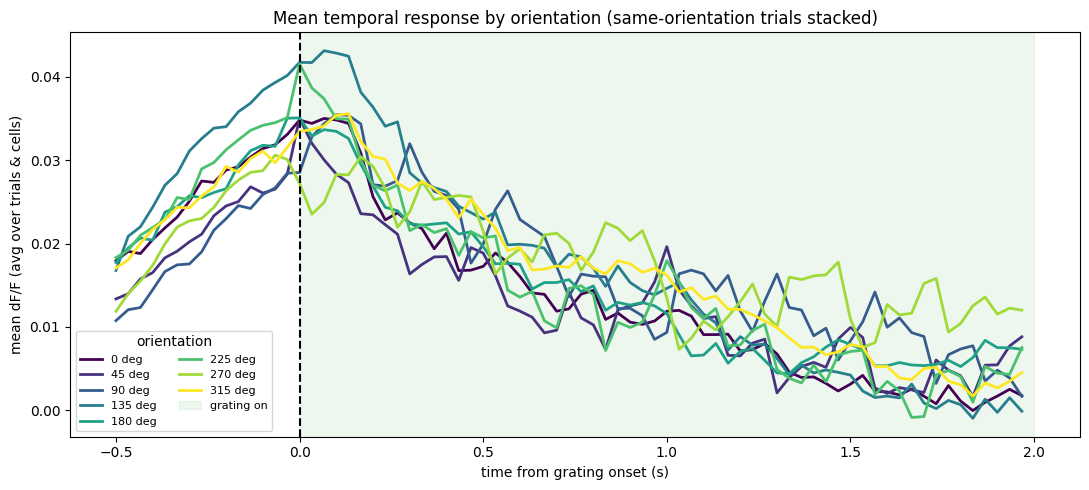

In [14]:
# --- Mean temporal response by stimulus: stack same-orientation trials, aligned to onset ---
# Intuition: many repeats of the SAME stimulus, aligned to onset and averaged, cancel the
# trial-to-trial noise and reveal the evoked dF/F waveform. We average over trials AND neurons,
# one curve per orientation (pooling the 5 TFs), so we see the temporal response within a trial.
fs = 30
pre, post = int(0.5 * fs), int(2.0 * fs)      # 0.5 s baseline + 2 s stimulus window
win = pre + post
t_rel = (np.arange(win) - pre) / fs            # time relative to grating onset (s)

orivals = np.unique(stim_table.orientation.dropna().values)
colors = plt.cm.viridis(np.linspace(0, 1, len(orivals)))

plt.figure(figsize=(11, 5))
for oi, ori in enumerate(orivals):
    snips = []
    for _, row in stim_table[stim_table.orientation == ori].iterrows():
        s = int(row.start) - pre
        seg = dff[:, s:s + win]                 # (n_cells, win)
        if s >= 0 and seg.shape[1] == win:
            snips.append(seg.mean(axis=0))      # mean over cells -> (win,)
    if snips:
        plt.plot(t_rel, np.mean(snips, axis=0), color=colors[oi], lw=2,
                 label=f"{int(ori)} deg")       # mean over trials -> (win,)

plt.axvspan(0, 2.0, color="tab:green", alpha=0.08, label="grating on")
plt.axvline(0, ls="--", color="k")
plt.xlabel("time from grating onset (s)")
plt.ylabel("mean dF/F (avg over trials & cells)")
plt.title("Mean temporal response by orientation (same-orientation trials stacked)")
plt.legend(title="orientation", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

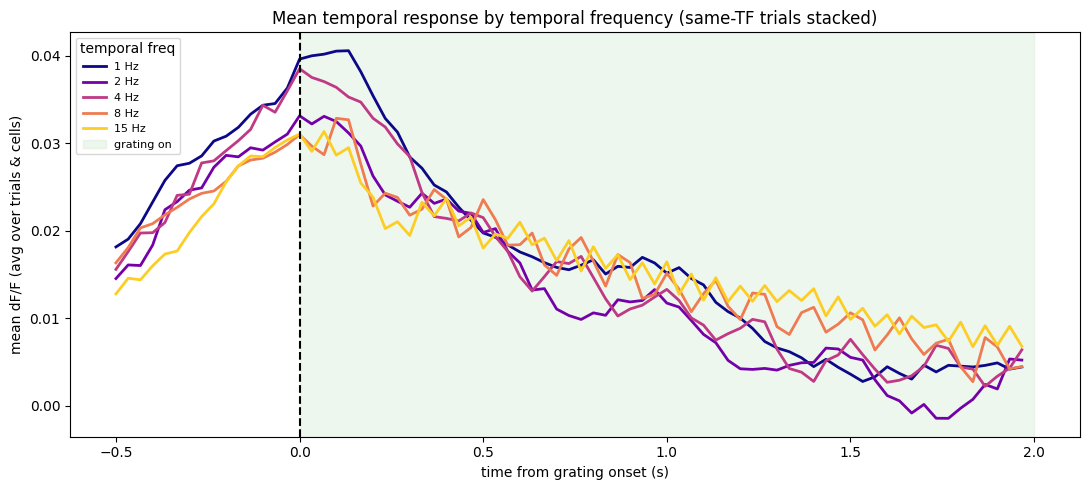

In [15]:
# --- Mean temporal response by TEMPORAL FREQUENCY: stack same-TF trials, aligned to onset ---
# Same idea as the orientation plot, but we group trials by temporal frequency (pooling
# the 8 directions). Averaging aligned repeats reveals the evoked dF/F waveform per TF.
fs = 30
pre, post = int(0.5 * fs), int(2.0 * fs)      # 0.5 s baseline + 2 s stimulus window
win = pre + post
t_rel = (np.arange(win) - pre) / fs            # time relative to grating onset (s)

tfvals_s = np.unique(stim_table.temporal_frequency.dropna().values)
colors = plt.cm.plasma(np.linspace(0, 0.9, len(tfvals_s)))

plt.figure(figsize=(11, 5))
for ti, tf in enumerate(tfvals_s):
    snips = []
    for _, row in stim_table[stim_table.temporal_frequency == tf].iterrows():
        s = int(row.start) - pre
        seg = dff[:, s:s + win]                 # (n_cells, win)
        if s >= 0 and seg.shape[1] == win:
            snips.append(seg.mean(axis=0))      # mean over cells -> (win,)
    if snips:
        plt.plot(t_rel, np.mean(snips, axis=0), color=colors[ti], lw=2,
                 label=f"{int(tf)} Hz")         # mean over trials -> (win,)

plt.axvspan(0, 2.0, color="tab:green", alpha=0.08, label="grating on")
plt.axvline(0, ls="--", color="k")
plt.xlabel("time from grating onset (s)")
plt.ylabel("mean dF/F (avg over trials & cells)")
plt.title("Mean temporal response by temporal frequency (same-TF trials stacked)")
plt.legend(title="temporal freq", fontsize=8)
plt.tight_layout(); plt.show()

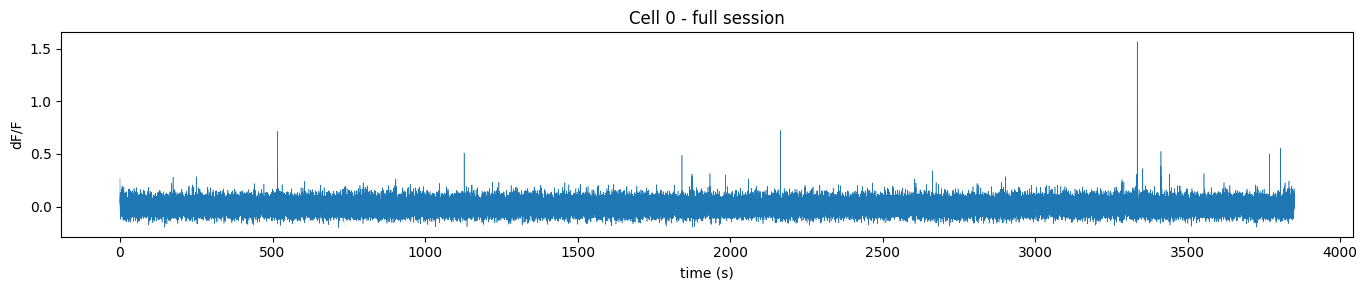

In [16]:
plt.figure(figsize=(14, 3))
plt.plot(t, dff[0], lw=0.4)
plt.xlabel("time (s)"); plt.ylabel("dF/F")
plt.title("Cell 0 - full session"); plt.tight_layout(); plt.show()

**(b) `stim_table` - the stimulus log.** Each row is one grating presentation: its `orientation`, `temporal_frequency`, and the `start`/`end` frame indices into `dff`. Rows with `NaN` orientation are **blank sweeps** (grey screen) - our baseline. There are **8 orientations x 5 temporal frequencies = 40 conditions**, each repeated many times.

In [17]:
print("orientations (deg):", np.unique(stim_table.orientation.dropna().values))
print("temporal freqs (Hz):", np.unique(stim_table.temporal_frequency.dropna().values))
print("total presentations:", len(stim_table),
      "| blank sweeps:", int(stim_table.orientation.isna().sum()))
stim_table.head(20)

orientations (deg): [  0.  45.  90. 135. 180. 225. 270. 315.]
temporal freqs (Hz): [ 1.  2.  4.  8. 15.]
total presentations: 628 | blank sweeps: 29


,temporal_frequency,orientation,blank_sweep,start,end
0,8.0,225.0,0.0,746,806
1,4.0,270.0,0.0,836,896
2,15.0,45.0,0.0,927,986
3,4.0,180.0,0.0,1017,1077
4,1.0,270.0,0.0,1107,1167
5,1.0,180.0,0.0,1198,1257
6,8.0,315.0,0.0,1288,1348
7,15.0,225.0,0.0,1378,1438
8,1.0,180.0,0.0,1468,1528
9,15.0,135.0,0.0,1559,1618


**(c) `trial_response` - one number per trial per cell.** For each presentation we averaged the neuron's `dF/F` over that grating's frames.


In [18]:
trial_response


,0,1,2,3,4,5,6,7,8,9,...,84,85,86,87,88,89,90,91,92,93
0,-0.003774,-0.046146,0.00348,0.007597,0.002234,0.017076,-0.000597,0.621905,0.004734,0.009445,...,0.006201,0.007017,0.004126,0.002801,0.004843,-0.004283,-0.002296,0.01354,-0.016526,0.003265
1,0.015337,0.08078,0.09196,0.004334,0.007513,0.009025,-0.002539,0.005211,0.0075,-0.011793,...,-0.010271,0.033906,-0.008921,0.014317,-0.004726,0.001848,0.137626,0.011823,0.006653,0.010998
2,0.01313,0.011891,0.031203,0.01111,-0.002808,0.004733,0.00429,-0.015928,0.036006,-0.01539,...,0.027458,0.008417,0.012975,0.015436,0.015581,-0.002154,-0.005524,0.006384,0.010906,0.005963
3,0.017919,0.017461,0.020195,0.001348,0.009283,0.008555,0.013668,0.548611,0.004279,0.040302,...,0.004644,0.008389,-0.002557,-0.004076,0.000219,0.011717,-0.003268,0.007107,-0.012456,0.005878
4,0.00964,-0.002019,0.014111,0.007739,0.006223,-0.002296,-0.00512,-0.01408,-0.004938,0.041112,...,0.008082,0.00537,0.011522,-0.001534,0.009408,-0.001442,0.010765,0.006456,0.208841,0.004207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623,-0.009422,-0.002567,-0.005276,0.001226,0.006677,0.006262,-0.004975,0.403576,-0.001064,-0.017446,...,0.003264,0.000897,-0.002041,-0.001164,-0.005097,0.005197,0.001646,0.003023,-0.002774,0.000973
624,-0.001589,0.076341,0.001366,0.003848,0.019324,0.010035,-0.006389,0.919535,0.009233,0.055869,...,0.001359,0.002911,-0.000171,0.00868,-0.008459,0.013521,0.003012,0.006319,0.001134,0.001071
625,-0.004386,-0.025171,0.008922,0.005243,-0.004542,-0.008358,0.00255,0.650277,-0.00341,0.00145,...,0.007068,-0.001556,-0.002229,0.011383,0.00013,0.003832,-0.003322,0.005383,0.004748,0.008852
626,-0.009002,0.007601,-0.002382,-0.010139,-0.002972,0.010982,-0.003271,0.202183,-0.004327,-0.004169,...,-0.004166,0.012845,0.001339,0.007509,-0.001506,0.008246,0.000632,-0.008206,-0.006177,-0.002823


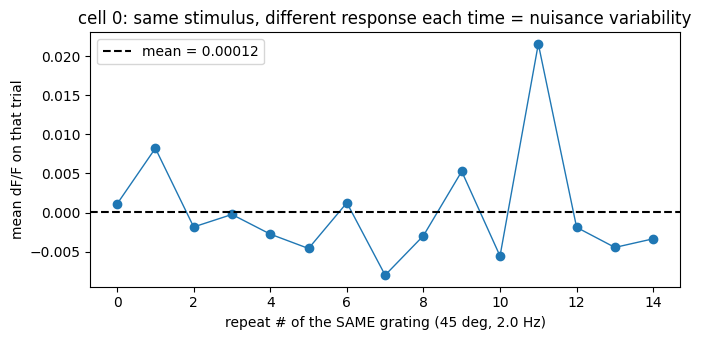

In [19]:
# pick one cell and one condition; show how much its response varies across repeats
# Interpreting one point: if the dot at x = 3 sits at y = 0.19, that reads as:
#"the 4th time cell 0 saw the 45°/2 Hz grating, its average dF/F over that trial was 0.19.
cell = 0
ori0, tf0 = 45.0, 2.0
mask = (stim_table.orientation == ori0) & (stim_table.temporal_frequency == tf0)
repeats = trial_response.loc[mask.values, str(cell)].astype(float).values

plt.figure(figsize=(7, 3.5))
plt.plot(repeats, "o-", lw=1)
plt.axhline(repeats.mean(), color="k", ls="--", label=f"mean = {repeats.mean():.5f}")
plt.xlabel(f"repeat # of the SAME grating ({int(ori0)} deg, {tf0} Hz)")
plt.ylabel("mean dF/F on that trial")
plt.title(f"cell {cell}: same stimulus, different response each time = nuisance variability")
plt.legend(); plt.tight_layout(); plt.show()

**(d) `tuning_array` - the trial-averaged summary.** For each of the 40 conditions we averaged over repeats and subtracted the blank. The result, `(8 orientations x 5 TF x n_cells)`, is each neuron's **tuning**: how strongly it responds to each grating. Averaging over repeats is exactly the step that removes the trial-to-trial nuisance and keeps the reliable signal.

What's the shape of this array? Remind yourself what these axes are.

In [20]:
tuning_array.shape
# tuning_array[:, :, :]

(8, 5, 94)

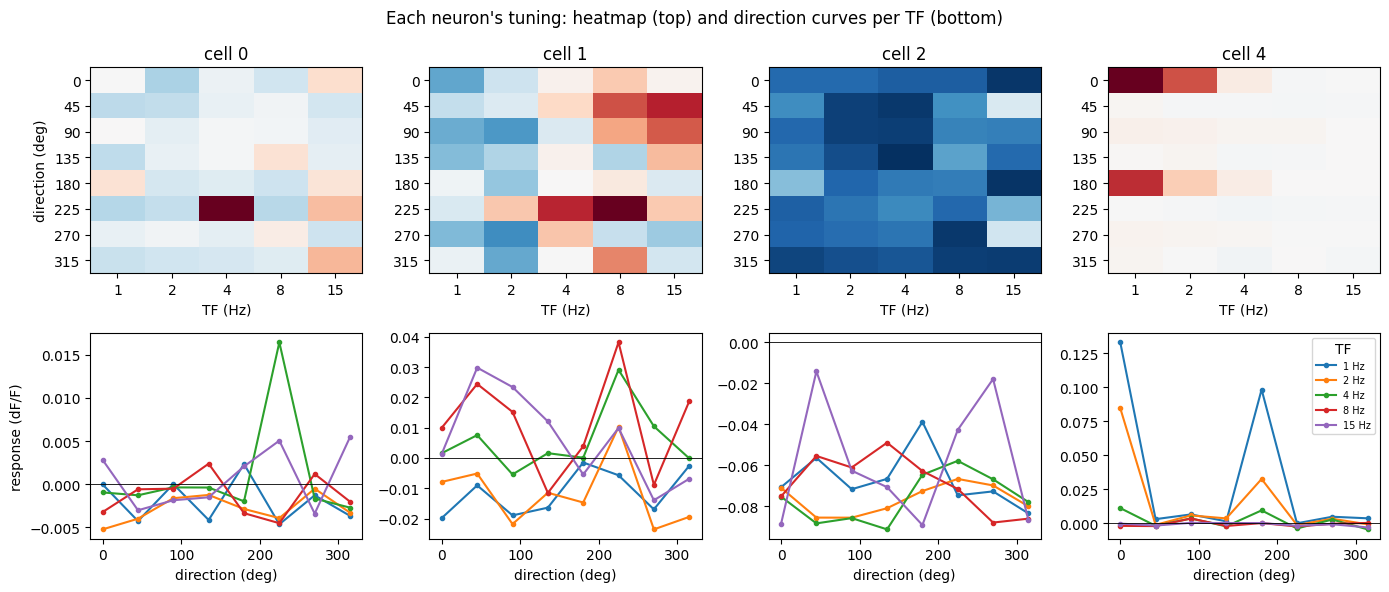

In [21]:
dirs_deg = np.arange(0, 360, 45)          # 8 directions
tfvals   = np.array([1., 2., 4., 8., 15.]) # 5 temporal frequencies (Hz)

example_cells = [0, 1, 2, 4]
fig, axes = plt.subplots(2, len(example_cells), figsize=(14, 6))
for k, cell in enumerate(example_cells):
    g = tuning_array[:, :, cell]           # (8 dir, 5 TF)

    # top row: heatmap
    ax = axes[0, k]
    im = ax.imshow(g, cmap="RdBu_r", vmin=-np.abs(g).max(), vmax=np.abs(g).max(), aspect="auto")
    ax.set_xticks(range(5)); ax.set_xticklabels(tfvals.astype(int))
    ax.set_yticks(range(8)); ax.set_yticklabels(dirs_deg)
    ax.set_title(f"cell {cell}")
    if k == 0: ax.set_ylabel("direction (deg)")
    ax.set_xlabel("TF (Hz)")

    # bottom row: tuning CURVES (response vs direction, one line per TF)
    ax = axes[1, k]
    for j, tf in enumerate(tfvals):
        ax.plot(dirs_deg, g[:, j], marker="o", ms=3, label=f"{int(tf)} Hz")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("direction (deg)")
    if k == 0: ax.set_ylabel("response (dF/F)")
    if k == len(example_cells) - 1: ax.legend(fontsize=7, title="TF")

fig.suptitle("Each neuron's tuning: heatmap (top) and direction curves per TF (bottom)")
plt.tight_layout(); plt.show()

Text(0.5, 1.0, 'Cell 4')

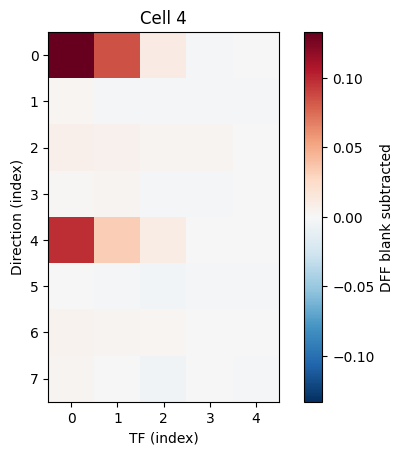

In [22]:
cell_id=4 #pick a cell index
plt.imshow(tuning_array[:,:,cell_id], cmap='RdBu_r', vmax=tuning_array[:,:,cell_id].max(), vmin=-1*tuning_array[:,:,cell_id].max())

plt.xlabel("TF (index)")
plt.ylabel("Direction (index)")

cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")
plt.title("Cell "+str(cell_id)) #Add a title so we know what the plot is of

We want to use this 2-dimensional tuning array to predict what brain region the neuron belonged to. This is easier if we can turn this 2D array into a 1D vector. To do that we'll use the function `np.reshape` to flatten our tuning_array.

In [23]:
ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])

Now look at the shape of the resulting array. What are these dimensions?

In [24]:
ta_flatten.shape

(40, 94)

Let's plot the flattened tuning array for the same neuron as above.

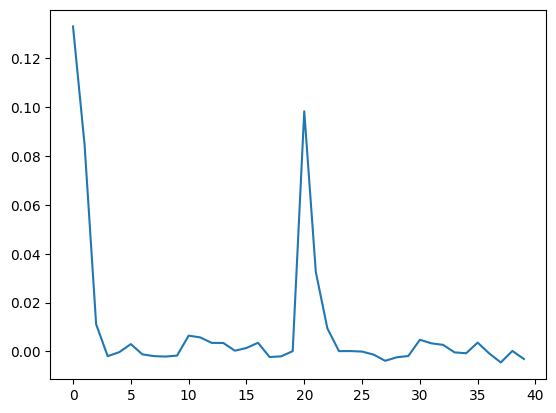

In [25]:
plt.plot(ta_flatten[:,cell_id])

And, for completeness, you can restore the original 2D tuning curve using the `np.reshape` function.

In [26]:
ta_reshape = ta_flatten[:,cell_id].reshape((8,5)) #this reshapes just our chosen neuron

Plot this to confirm we have the same original plot:

Text(0.5, 1.0, 'Cell 4')

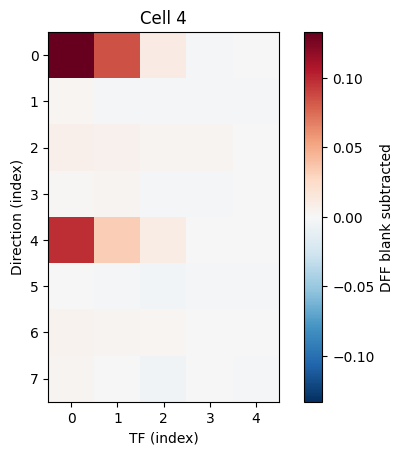

In [27]:
plt.imshow(ta_reshape[:,:], cmap='RdBu_r', vmax=ta_reshape.max(), vmin=-1*ta_reshape.max())

plt.xlabel("TF (index)")
plt.ylabel("Direction (index)")

cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")
plt.title("Cell "+str(cell_id)) #Add a title so we know what the plot is of



---



Okay, now that we've demonstrated what we want to do for all the neurons, let's
get to business!

Use function to compute 2D tuning array for all PM sessions. Flatten the tuning array from the session, and append the result to a growing list of tuning data.

In [28]:
#create an empty array to contain the results
tuning_pm = np.empty((40,0))
session_pm = []  # track which session each neuron came from (needed for grouped CV)

#for each session
for pmid in exps_pm.id:
    print("Session ID: ", pmid)
    #compute the 2D tuning array
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(pmid)
    #flatten the array from (8,5,numbercells) to (40,numbercells)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    #append the result to the array for results
    tuning_pm = np.append(tuning_pm, ta_flatten, axis=1)
    #record this session's id once per neuron it contributed
    session_pm.extend([pmid] * ta_flatten.shape[1])

Session ID:  504115289
Number of cells:  94
Session ID:  502666254
Number of cells:  90
Session ID:  658854537
Number of cells:  112
Session ID:  512311673
Number of cells:  70
Session ID:  510859641
Number of cells:  124
Session ID:  503324629
Number of cells:  167
Session ID:  657914280
Number of cells:  84
Session ID:  502376461
Number of cells:  106
Session ID:  506773185
Number of cells:  101


What is the shape of your resulting array?

In [29]:
tuning_pm.shape

(40, 948)

Repeat this for the AL data.

In [30]:
tuning_al = np.empty((40,0))
session_al = []  # track which session each neuron came from (needed for grouped CV)

for alid in exps_al.id:
    print("Session ID: ", alid)
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(alid)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    tuning_al = np.append(tuning_al, ta_flatten, axis=1)
    session_al.extend([alid] * ta_flatten.shape[1])

Session ID:  506773892
Number of cells:  76
Session ID:  557225279
Number of cells:  47
Session ID:  503412730
Number of cells:  119
Session ID:  502199136
Number of cells:  159
Session ID:  501876401
Number of cells:  181
Session ID:  501933264
Number of cells:  217


What is the shape of this array?

In [31]:
tuning_al.shape

(40, 799)

## 4. Signal vs nuisance: what actually differs between the areas?

Before modelling, we look at the **average tuning of each area**. If PM and AL differ on average, that difference is the *signal* a decoder can use. Anything that varies neuron-to-neuron or session-to-session but not systematically by area is *nuisance*.

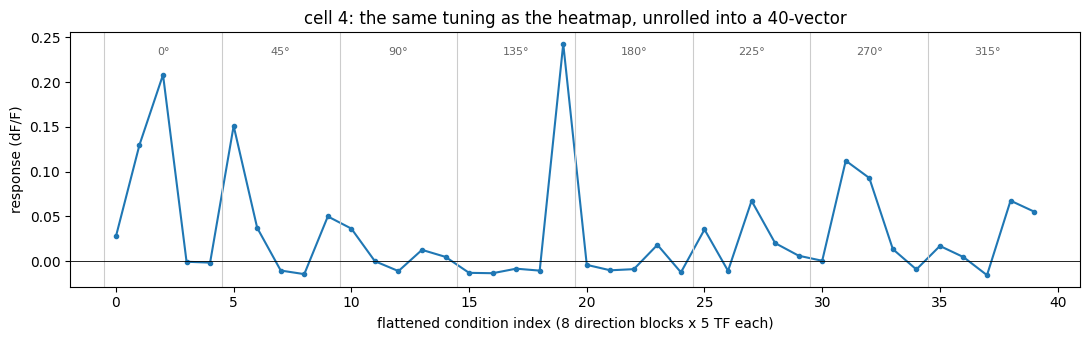

In [32]:
# plot one neuron's 40-vector; mark the 8 direction blocks (5 TFs each)
cell_id = 4
plt.figure(figsize=(11, 3.5))
plt.plot(ta_flatten[:, cell_id], marker="o", ms=3)
for d in range(8):
    plt.axvline(d * 5 - 0.5, color="0.8", lw=0.8)        # block boundary
    plt.text(d * 5 + 2, plt.ylim()[1] * 0.9, f"{d*45}\u00b0", ha="center", fontsize=8, color="0.4")
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("flattened condition index (8 direction blocks x 5 TF each)")
plt.ylabel("response (dF/F)")
plt.title(f"cell {cell_id}: the same tuning as the heatmap, unrolled into a 40-vector")
plt.tight_layout(); plt.show()



---
Now that we have our tuning arrays for all the neurons in PM and AL, we want to create a labels for each neuron. We'll label PM as 0 and AL as 1.



In [33]:
label = np.repeat(0,tuning_pm.shape[1]) #create a vector of 0's as long as the PM neurons
label = np.append(label, np.repeat(1,tuning_al.shape[1])) #append a vector of 1's as long as the AL neurons
len(label)

1747

Plot this to confirm it looks like you expect.

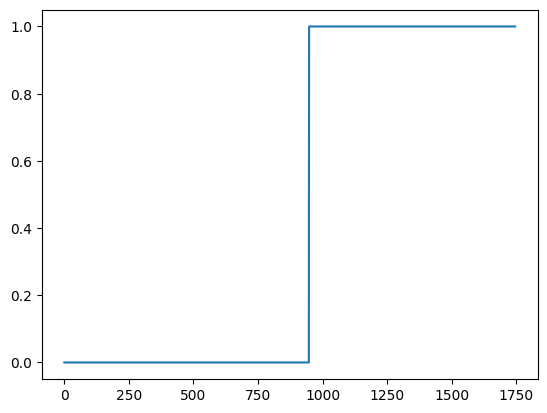

In [34]:
plt.plot(label)

Now let's append the two tuning arrays together. Do PM first and then AL to match the labels.

In [35]:
tuning = np.append(tuning_pm, tuning_al, axis=1)

In [36]:
tuning.shape

(40, 1747)

Notice that our label vector is as long as our tuning array.

The challenge in this project is to use classification methods to determine the correct label for a neuron based on its tuning. You can try a variety of methods and determine which ones work best, and how well you can differentiate these two regions (it won't be perfect!).

You will want to set up some hold out data to test your classification methods. So let's do that now. We will create a random list of integers to remove from these arrays. First, set a seed so that we create the same random selection if we rerun this code. Set the seed variable with your favorite number.

In [37]:
# Create a generator instance with a specific seed. Feel free to change the seed to the number of your choosing
rng = np.random.default_rng(seed=0)

Now get random numbers from the range of the number of neurons we have here. We'll select 200 neurons - but you can change this if you want to hold out more or less data.
This serves as an index into your tuning array and label vector.

In [38]:
total_cells = len(label)
holdout_length = 200
holdout = np.random.choice(range(total_cells), holdout_length, replace=False)

Use this to separate your tuning and label into a holdout set and a training set.

In [39]:
tuning_holdout = tuning[:,holdout]
tuning_holdout.shape

(40, 200)

In [40]:
tuning_train = np.delete(tuning, holdout, axis=1)
tuning_train.shape

(40, 1547)

In [41]:
label_holdout = label[holdout]
label_holdout.shape

(200,)

In [42]:
label_train = np.delete(label, holdout)
len(label_train)

1547

From here, use your tuning_train and label_train to train classifier to best predict the brain region that each neuron is from. Sklearn has a number of classification methods that you can use and compare.


## 4. Signal vs nuisance: what actually differs between the areas?

Before modelling, we look at the **average tuning of each area**. If PM and AL differ on average, that difference is the *signal* a decoder can use. Anything that varies neuron-to-neuron or session-to-session but not systematically by area is *nuisance*.

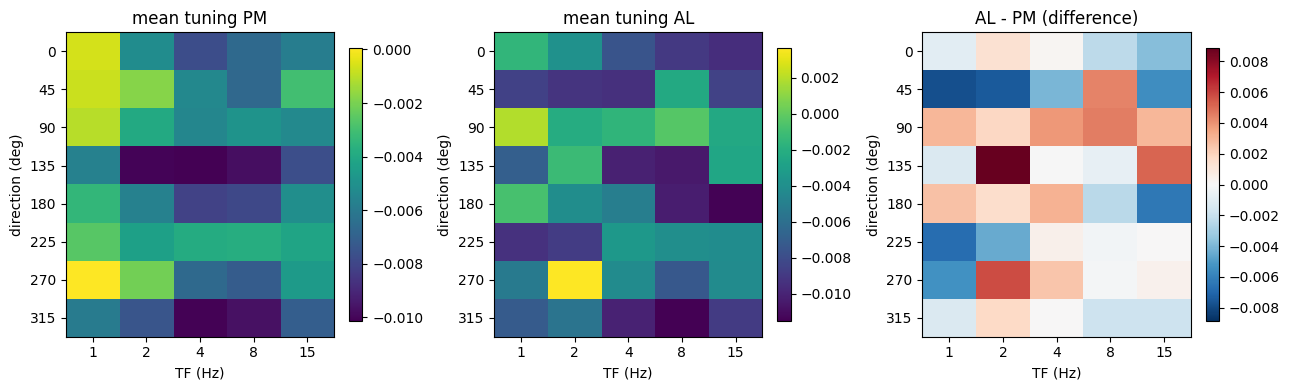

In [43]:
# mean 40-vector per area, reshaped back to the 8x5 grid for reading.
# tuning is (40 features, n_cells), so we select columns by area and average across neurons.
mean_pm = tuning[:, label == 0].mean(axis=1).reshape(8, 5) # average across CELLS
mean_al = tuning[:, label == 1].mean(axis=1).reshape(8, 5) # average across CELLS
diff    = mean_al - mean_pm

vmax = np.abs(np.concatenate([mean_pm, mean_al])).max()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, g, title, cmap, vlim in [
    (axes[0], mean_pm, "mean tuning PM", "viridis", (None, None)),
    (axes[1], mean_al, "mean tuning AL", "viridis", (None, None)),
    (axes[2], diff,    "AL - PM (difference)", "RdBu_r", (-np.abs(diff).max(), np.abs(diff).max())),
]:
    im = ax.imshow(g, cmap=cmap, aspect="auto", vmin=vlim[0], vmax=vlim[1])
    ax.set_xticks(range(5)); ax.set_xticklabels(tfvals.astype(int))
    ax.set_yticks(range(8)); ax.set_yticklabels(dirs_deg)
    ax.set_xlabel("TF (Hz)"); ax.set_ylabel("direction (deg)")
    ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.046)
    # cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
plt.tight_layout(); plt.show()

the right panel is their difference (red = AL responds more, blue = PM more). The differences are small (~0.008 dF/F) and patchy, with a mild tendency for AL to respond more at some low/mid-TF conditions (e.g. ~135°, 2 Hz). Takeaway: the two areas do differ, but only weakly at the single-neuron level — so we should expect a decoder modestly above chance, not perfect. That is an honest result, not a failure.

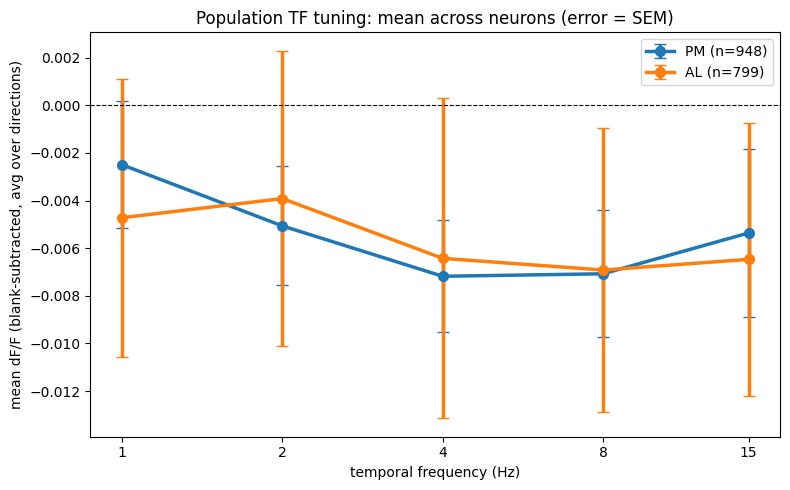

In [44]:
# --- Population TF tuning: MEAN across all neurons at each temporal frequency (PM vs AL) ---
# Collapse the 8 directions per neuron -> a response-vs-TF curve, then average over ALL
# neurons of each area. Error bars = SEM (std / sqrt(n)) so we compare the area means.
tf_curves = tuning.T.reshape(-1, 8, 5).mean(axis=1)   # (n_cells, 5), avg over directions

plt.figure(figsize=(8, 5))
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    grp = tf_curves[label == lab]
    m   = grp.mean(axis=0)                       # mean across neurons at each TF
    sem = grp.std(axis=0) / np.sqrt(len(grp))    # standard error of that mean
    plt.errorbar(tfvals, m, yerr=sem, color=c, lw=2.5, marker="o", ms=7,
                 capsize=4, label=f"{name} (n={len(grp)})")

plt.axhline(0, color="k", lw=0.8, ls="--")       # blank baseline reference
plt.xscale("log", base=2)                        # TF is ~log-spaced (1, 2, 4, 8, 15)
plt.xticks(tfvals, tfvals.astype(int))
plt.xlabel("temporal frequency (Hz)")
plt.ylabel("mean dF/F (blank-subtracted, avg over directions)")
plt.title("Population TF tuning: mean across neurons (error = SEM)")
plt.legend(); plt.tight_layout(); plt.show()

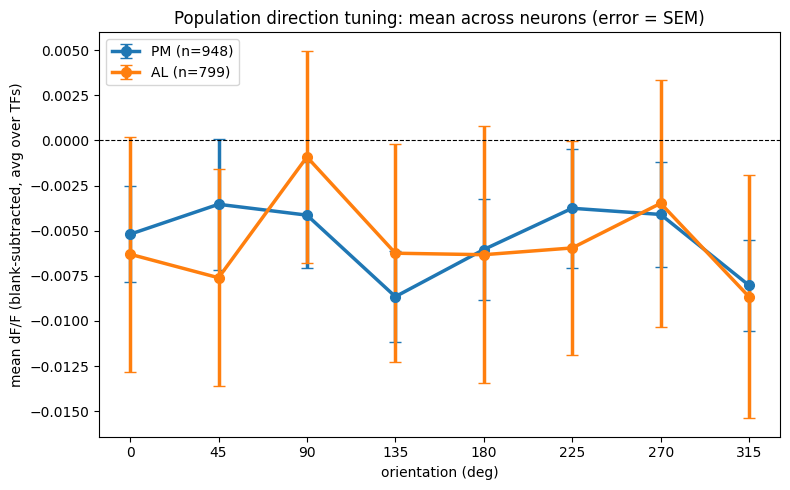

In [45]:
# --- Population DIRECTION tuning: MEAN across all neurons at each direction (PM vs AL) ---
# Collapse the 5 temporal frequencies per neuron -> a response-vs-direction curve, then
# average over ALL neurons of each area. Error bars = SEM (std / sqrt(n)).
dir_curves = tuning.T.reshape(-1, 8, 5).mean(axis=2)   # (n_cells, 8), avg over the 5 TFs

plt.figure(figsize=(8, 5))
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    grp = dir_curves[label == lab]
    m   = grp.mean(axis=0)                       # mean across neurons at each direction
    sem = grp.std(axis=0) / np.sqrt(len(grp))    # standard error of that mean
    plt.errorbar(dirs_deg, m, yerr=sem, color=c, lw=2.5, marker="o", ms=7,
                 capsize=4, label=f"{name} (n={len(grp)})")

plt.axhline(0, color="k", lw=0.8, ls="--")       # blank baseline reference
plt.xticks(dirs_deg)
plt.xlabel("orientation (deg)")
plt.ylabel("mean dF/F (blank-subtracted, avg over TFs)")
plt.title("Population direction tuning: mean across neurons (error = SEM)")
plt.legend(); plt.tight_layout(); plt.show()

## 5. before classification: PCA and t-SNE

A quick, model-free way to ask "is there any area structure at all?" is to compress each 40-vector to 2D and colour the points. We do this two ways:
- coloured by **area** - do PM and AL separate?
- coloured by **session** - if points cluster by session instead of area, that warns us of a **session/batch effect** we must guard against in cross-validation.

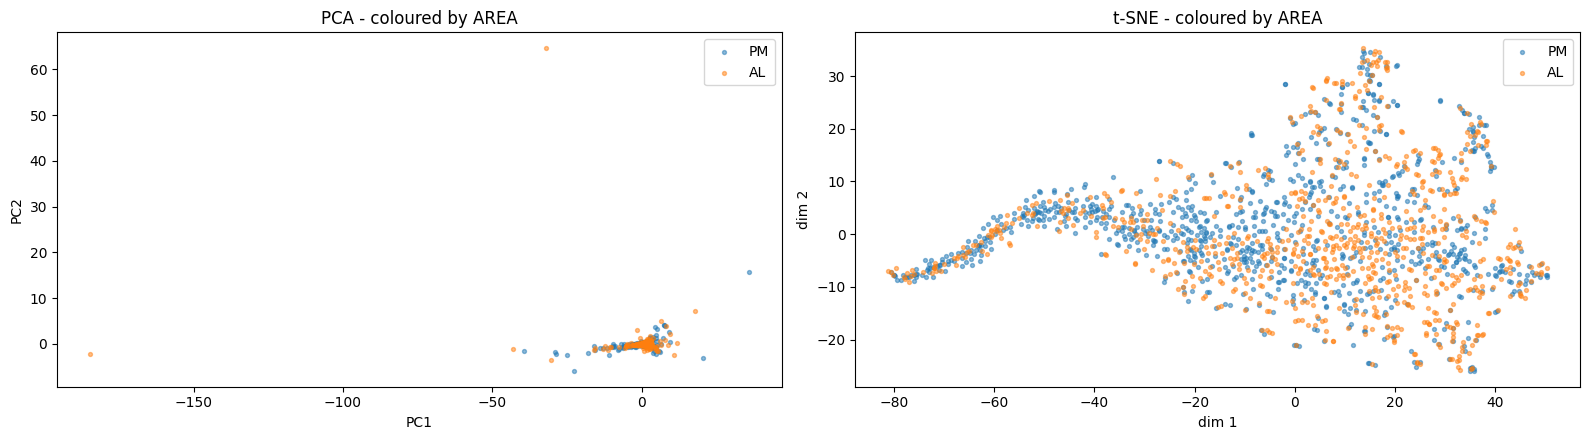

In [95]:
# standardize features (each of the 40 to mean 0, std 1) before PCA/t-SNE
Xz = StandardScaler().fit_transform(tuning.T)   # tuning.T = one row per neuron

pca = PCA(n_components=2).fit_transform(Xz)
tsne = TSNE(n_components=2, random_state=0, init="pca").fit_transform(Xz)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

# PCA coloured by area
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    m = label == lab
    axes[0].scatter(pca[m, 0], pca[m, 1], s=8, alpha=0.5, color=c, label=name)
axes[0].set_title("PCA - coloured by AREA"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

groups = np.concatenate([session_pm, session_al])
# PCA coloured by session (leakage check)
# for s in np.unique(groups):
#     m = groups == s
#     axes[1].scatter(pca[m, 0], pca[m, 1], s=8, alpha=0.5)
# axes[1].set_title("PCA - coloured by SESSION (leakage check)"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

# t-SNE coloured by area
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    m = label == lab
    axes[1].scatter(tsne[m, 0], tsne[m, 1], s=8, alpha=0.5, color=c, label=name)
axes[1].set_title("t-SNE - coloured by AREA"); axes[1].set_xlabel("dim 1"); axes[1].set_ylabel("dim 2"); axes[1].legend()

plt.tight_layout(); plt.show()

AL and PM are only weakly separable at the single-neuron level — heavy overlap, no clean cluster.

### 6a. One feature, one threshold

Our single feature is **weighted temporal frequency** (`weighted_tf`): for each neuron, average its tuning over direction to get a response-vs-TF curve, then take the TF "centre of mass". A neuron that responds most to fast gratings gets a high value. This directly encodes the AL(fast)/PM(slow) hypothesis from section 4.

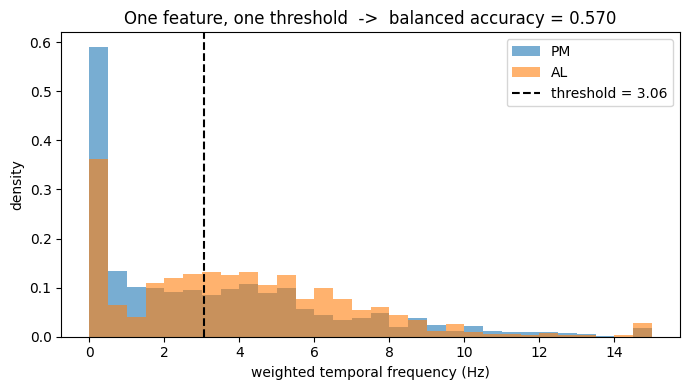

PM median wTF = 2.41 Hz | AL median wTF = 3.72 Hz
hand threshold balanced accuracy = 0.570 (chance = 0.5)


In [47]:
def weighted_tf(X40):
    """One interpretable number per neuron: the temporal-frequency centre of mass."""
    out = np.empty(len(X40))
    for i, v in enumerate(X40):
        g = v.reshape(8, 5)                       # (direction, TF)
        tf_curve = np.clip(g.mean(axis=0), 0, None)  # response vs TF (rectified) #averages responses across all 8 directions for each of the 5 TFs
        p = tf_curve / (tf_curve.sum() + 1e-9)
        out[i] = np.sum(p * tfvals)
    return out

wtf = weighted_tf(tuning.T)   # one value per neuron

# distributions per area + a hand-picked threshold (midpoint of the two medians)
thr = 0.5 * (np.median(wtf[label == 0]) + np.median(wtf[label == 1]))
pred_thr = (wtf > thr).astype(int)               # above threshold -> guess AL (1)
bal = balanced_accuracy_score(label, pred_thr)

plt.figure(figsize=(7, 4))
plt.hist(wtf[label == 0], bins=30, alpha=0.6, density=True, label="PM")
plt.hist(wtf[label == 1], bins=30, alpha=0.6, density=True, label="AL")
plt.axvline(thr, color="k", ls="--", label=f"threshold = {thr:.2f}")
plt.xlabel("weighted temporal frequency (Hz)"); plt.ylabel("density")
plt.title(f"One feature, one threshold  ->  balanced accuracy = {bal:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

print(f"PM median wTF = {np.median(wtf[label==0]):.2f} Hz | AL median wTF = {np.median(wtf[label==1]):.2f} Hz")
print(f"hand threshold balanced accuracy = {bal:.3f} (chance = 0.5)")

### 6b. One feature, logistic regression, session-grouped CV

The hand threshold above was measured on the same data we picked it from, so it is optimistic. Now we do it honestly: let logistic regression learn the boundary on training sessions and score it on **held-out sessions**. We build folds so that whole sessions stay together and every test fold contains both areas.

In [48]:
def balanced_group_folds(y, groups, n_splits, seed=0):
    """Assign whole sessions to folds so every fold has both areas (round-robin per class)."""
    rng = np.random.default_rng(seed)
    fold = np.full(len(y), -1)
    for cls in np.unique(y):
        sess = np.unique(groups[y == cls]); rng.shuffle(sess)
        for i, s in enumerate(sess):
            fold[groups == s] = i % n_splits
    return fold

def grouped_cv_eval(Xf, y, groups, n_splits, seed=0, penalty="l2", C=1.0, return_preds=False):
    """Regularized logistic regression + StandardScaler, scored on held-out sessions.

    penalty : "l2" (ridge, default) or "l1" (lasso, which also zeroes out useless features)
    C       : inverse regularization strength -- SMALLER C = STRONGER regularization
    return_preds : also return the pooled out-of-fold true/predicted labels (for a confusion matrix)
    """
    Xf = Xf.reshape(len(Xf), -1)
    fold = balanced_group_folds(y, groups, n_splits, seed)
    solver = "liblinear" if penalty == "l1" else "lbfgs"   # l1 needs a compatible solver
    bals, aucs = [], []
    y_true_oof, y_pred_oof = [], []
    for k in range(n_splits):
        tr, va = fold != k, fold == k
        if len(np.unique(y[va])) < 2:
            continue
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("clf", LogisticRegression(penalty=penalty, C=C,
                                                    solver=solver, max_iter=5000, class_weight="balanced"))])
        pipe.fit(Xf[tr], y[tr])
        p = pipe.predict_proba(Xf[va])[:, 1]
        pred = (p > 0.5).astype(int)
        bals.append(balanced_accuracy_score(y[va], pred))
        aucs.append(roc_auc_score(y[va], p))
        y_true_oof.append(y[va]); y_pred_oof.append(pred)
    if return_preds:
        return (np.array(bals), np.array(aucs),
                np.concatenate(y_true_oof), np.concatenate(y_pred_oof))
    return np.array(bals), np.array(aucs)

# number of folds is limited by the area with fewer sessions
n_splits = min(5, len(np.unique(session_pm)), len(np.unique(session_al)))
print("n_splits:", n_splits)

bal1, auc1 = grouped_cv_eval(wtf, label, groups, n_splits)
print(f"[1 feature: weighted_tf]  balanced acc {bal1.mean():.3f} +/- {bal1.std():.3f}"
      f" | AUC {auc1.mean():.3f} +/- {auc1.std():.3f}   (chance 0.5)")

n_splits: 5
[1 feature: weighted_tf]  balanced acc 0.562 +/- 0.051 | AUC 0.594 +/- 0.067   (chance 0.5)


### 6c. All 40 features, logistic regression

Does using the whole tuning vector beat the single hand-designed feature? Same model, same folds, just more input columns.

[40 features: full tuning]  balanced acc 0.564 +/- 0.057 | AUC 0.564 +/- 0.055   (chance 0.5)


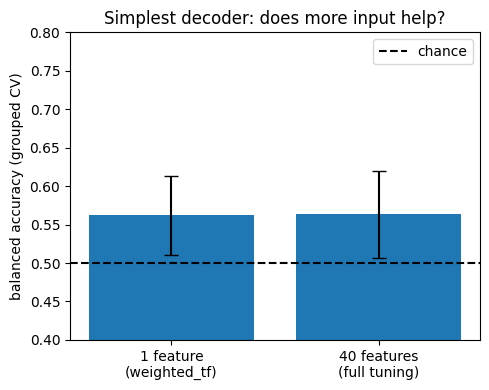

In [49]:
bal40, auc40 = grouped_cv_eval(tuning.T, label, groups, n_splits)
print(f"[40 features: full tuning]  balanced acc {bal40.mean():.3f} +/- {bal40.std():.3f}"
      f" | AUC {auc40.mean():.3f} +/- {auc40.std():.3f}   (chance 0.5)")

# compare the two models side by side
labels = ["1 feature\n(weighted_tf)", "40 features\n(full tuning)"]
means  = [bal1.mean(), bal40.mean()]
errs   = [bal1.std(),  bal40.std()]
plt.figure(figsize=(5, 4))
plt.bar(labels, means, yerr=errs, capsize=5)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.ylabel("balanced accuracy (grouped CV)"); plt.ylim(0.4, 0.8)
plt.title("Simplest decoder: does more input help?"); plt.legend()
plt.tight_layout(); plt.show()

### 6d. Confusion matrix: *which* area does it get wrong?

Balanced accuracy is one number; a confusion matrix shows the mistakes. We pool the **out-of-fold** predictions (each neuron is predicted once, while its own session is held out) from the 40-feature logistic regression, then read it two ways:
- **counts** - raw number of neurons in each true/predicted cell;
- **row-normalized** - each row divided by its total, so the diagonal is the **per-area recall** (fraction of PM neurons called PM, and of AL neurons called AL).

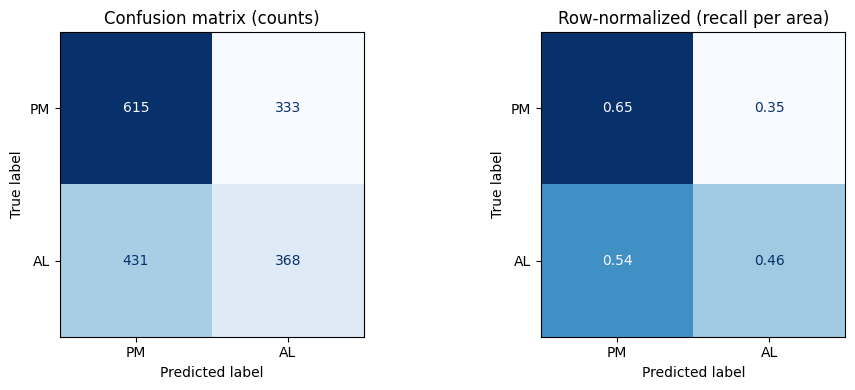

PM recall = 0.649 | AL recall = 0.461  (chance = 0.5)


In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

# pooled out-of-fold predictions from the 40-feature (L2-regularized) logistic regression
_, _, y_true, y_pred = grouped_cv_eval(tuning.T, label, groups, n_splits, return_preds=True)

cm = confusion_matrix(y_true, y_pred)                    # rows = true area, cols = predicted
cm_recall = cm / cm.sum(axis=1, keepdims=True)           # row-normalized -> per-area recall

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=["PM", "AL"]).plot(
    ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay(cm_recall, display_labels=["PM", "AL"]).plot(
    ax=ax[1], colorbar=False, cmap="Blues", values_format=".2f")
ax[1].set_title("Row-normalized (recall per area)")
plt.tight_layout(); plt.show()

print(f"PM recall = {cm_recall[0, 0]:.3f} | AL recall = {cm_recall[1, 1]:.3f}  (chance = 0.5)")

## 9. TF only: ignore direction entirely

Every feature so far mixed the 8 motion directions with the 5 temporal frequencies (the 40-value vector). Here we **drop direction completely**: average each neuron's response over its 8 directions, leaving a 5-value response-vs-TF curve per neuron.

`X_tf = mean_over_directions(tuning)`  ->  5 features instead of 40

Same session-grouped logistic regression, same folds. The question: **is the area signal carried by temporal-frequency tuning alone**, or did the 40-feature decoder (Section 6c) rely on direction information too?

X_tf shape: (1747, 5)
[TF only, 5 feats]        balanced acc 0.592 +/- 0.043 | AUC 0.592 +/- 0.075   (chance 0.5)
[full tuning, 40 feats]   balanced acc 0.564 | AUC 0.564  (Section 6c)


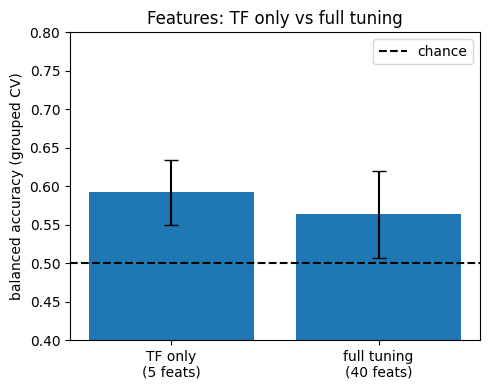

In [51]:
# --- Section 9: TF-only features (direction ignored), same decoder + folds ---
# Collapse each neuron's 8 directions -> a 5-value response-vs-TF curve. This is exactly
# the tf_curves used earlier, now used as the ONLY features (5 instead of 40).
X_tf = tuning.T.reshape(-1, 8, 5).mean(axis=1)        # (n_cells, 5), avg over the 8 directions
print("X_tf shape:", X_tf.shape)                       # sanity: (n_cells, 5)

# same session-grouped logistic regression and folds as Section 6c, for a fair comparison
bal_tf, auc_tf = grouped_cv_eval(X_tf, label, groups, n_splits)
print(f"[TF only, 5 feats]        balanced acc {bal_tf.mean():.3f} +/- {bal_tf.std():.3f}"
      f" | AUC {auc_tf.mean():.3f} +/- {auc_tf.std():.3f}   (chance 0.5)")
print(f"[full tuning, 40 feats]   balanced acc {bal40.mean():.3f} | AUC {auc40.mean():.3f}  (Section 6c)")

plt.figure(figsize=(5, 4))
plt.bar(["TF only\n(5 feats)", "full tuning\n(40 feats)"], [bal_tf.mean(), bal40.mean()],
        yerr=[bal_tf.std(), bal40.std()], capsize=5)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.ylabel("balanced accuracy (grouped CV)"); plt.ylim(0.4, 0.8)
plt.title("Features: TF only vs full tuning"); plt.legend()
plt.tight_layout(); plt.show()

Same idea as the earlier 8x5 mean-tuning heatmap, but with direction averaged out: each area's mean response across the 5 temporal frequencies, plus their difference. Because direction is dropped, the grid is a single row of 5 TF values per area instead of an 8x5 block.

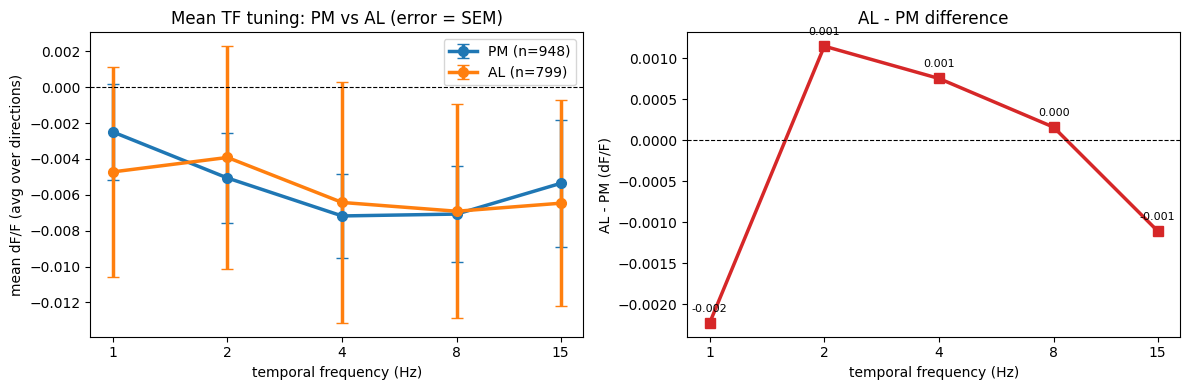

In [52]:
# --- Section 9: mean TF-only tuning per area as a line graph (direction dropped) ---
# X_tf is (n_cells, 5): each neuron's response averaged over the 8 directions.
# Only 5 values per area, so a line graph reads better than a heatmap.
tf_pm   = X_tf[label == 0].mean(axis=0)                 # average across PM cells -> (5,)
tf_al   = X_tf[label == 1].mean(axis=0)                 # average across AL cells -> (5,)
sem_pm  = X_tf[label == 0].std(axis=0) / np.sqrt((label == 0).sum())
sem_al  = X_tf[label == 1].std(axis=0) / np.sqrt((label == 1).sum())
tf_diff = tf_al - tf_pm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: PM and AL mean TF tuning (error bars = SEM)
axes[0].errorbar(tfvals, tf_pm, yerr=sem_pm, color="tab:blue", lw=2.5, marker="o", ms=7,
                 capsize=4, label=f"PM (n={int((label == 0).sum())})")
axes[0].errorbar(tfvals, tf_al, yerr=sem_al, color="tab:orange", lw=2.5, marker="o", ms=7,
                 capsize=4, label=f"AL (n={int((label == 1).sum())})")
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_xscale("log", base=2); axes[0].set_xticks(tfvals); axes[0].set_xticklabels(tfvals.astype(int))
axes[0].set_xlabel("temporal frequency (Hz)"); axes[0].set_ylabel("mean dF/F (avg over directions)")
axes[0].set_title("Mean TF tuning: PM vs AL (error = SEM)"); axes[0].legend()

# right: AL - PM difference (what a TF-only decoder can exploit)
axes[1].plot(tfvals, tf_diff, color="tab:red", lw=2.5, marker="s", ms=7)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xscale("log", base=2); axes[1].set_xticks(tfvals); axes[1].set_xticklabels(tfvals.astype(int))
axes[1].set_xlabel("temporal frequency (Hz)"); axes[1].set_ylabel("AL - PM (dF/F)")
axes[1].set_title("AL - PM difference")
for xf, yv in zip(tfvals, tf_diff):                     # annotate the 5 difference values
    axes[1].annotate(f"{yv:.3f}", (xf, yv), textcoords="offset points", xytext=(0, 8),
                     fontsize=8, ha="center")
plt.tight_layout(); plt.show()

## 10. Does the layer matter? Repeat in layer 4 (Rorb-IRES2-Cre)

Everything so far used the **layer 2/3** cohort (`Cux2-CreERT2` @ 175 um). Here we ask whether the area signal looks different in **layer 4**. Layer 4 needs a different Cre line, so we swap the cohort to `Rorb-IRES2-Cre` (taking all available depths, no depth filter), rebuild the *exact same* 40-value tuning dataset with the existing `build_area`/`compute_tuning`, and re-run both decoders: the **full 40-feature** tuning and the **TF-only** (direction-averaged, 5 features) version.

**Caveat:** switching to L4 changes the Cre line *and* the depth together, so any L2/3-vs-L4 difference we see is "layer + genotype", not layer in isolation. It is still a useful check on whether the modest area signal is layer-specific.

In [53]:
# --- Section 10: Layer 4 cohort (Rorb-IRES2-Cre), rebuild the same dataset ---
common_l4 = dict(cre_lines=['Rorb-IRES2-Cre'], stimuli=['drifting_gratings'])   # no depth filter: all L4 depths
exps_pm_l4 = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_l4))
exps_al_l4 = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_l4))
print(f"L4 VISpm sessions: {len(exps_pm_l4)} | depths: {sorted(exps_pm_l4.imaging_depth.unique()) if len(exps_pm_l4) else '-'}")
print(f"L4 VISal sessions: {len(exps_al_l4)} | depths: {sorted(exps_al_l4.imaging_depth.unique()) if len(exps_al_l4) else '-'}")

# reuse the SAME builders as the L2/3 dataset; (re)define them here if the earlier
# Section 2/3 cells were not run in this kernel, so this section works standalone.

def build_area(exps, verbose=False):
    vecs, sess = [], []
    for sid in exps.id:
        _, _, _, ta = compute_tuning(sid)
        flat = ta.reshape(-1, ta.shape[-1])   # (40, n_cells)
        vecs.append(flat)
        sess.extend([sid] * flat.shape[1])
    return np.hstack(vecs), np.array(sess)

tuning_pm_l4, session_pm_l4 = build_area(exps_pm_l4)
tuning_al_l4, session_al_l4 = build_area(exps_al_l4)

label_l4    = np.append(np.repeat(0, tuning_pm_l4.shape[1]), np.repeat(1, tuning_al_l4.shape[1]))
tuning_l4   = np.append(tuning_pm_l4, tuning_al_l4, axis=1)         # (40, n_cells_L4)
groups_l4   = np.concatenate([session_pm_l4, session_al_l4])
n_splits_l4 = min(5, len(np.unique(session_pm_l4)), len(np.unique(session_al_l4)))
print("L4 dataset:", tuning_l4.shape, "| PM cells:", int((label_l4 == 0).sum()),
      "| AL cells:", int((label_l4 == 1).sum()), "| n_splits:", n_splits_l4)

L4 VISpm sessions: 7 | depths: [275]
L4 VISal sessions: 6 | depths: [275]
Number of cells:  170
Number of cells:  43
Number of cells:  79
Number of cells:  42
Number of cells:  17
Number of cells:  60
Number of cells:  100
Number of cells:  87
Number of cells:  126
Number of cells:  207
Number of cells:  89
Number of cells:  51
Number of cells:  234
L4 dataset: (40, 1305) | PM cells: 511 | AL cells: 794 | n_splits: 5


[L4   full 40] bal 0.542 +/- 0.023 | AUC 0.505
[L4   TF only] bal 0.561 +/- 0.039 | AUC 0.536
[L2/3 full 40] bal 0.564 | AUC 0.564   (earlier sections)
[L2/3 TF only] bal 0.592 | AUC 0.592   (Section 9)


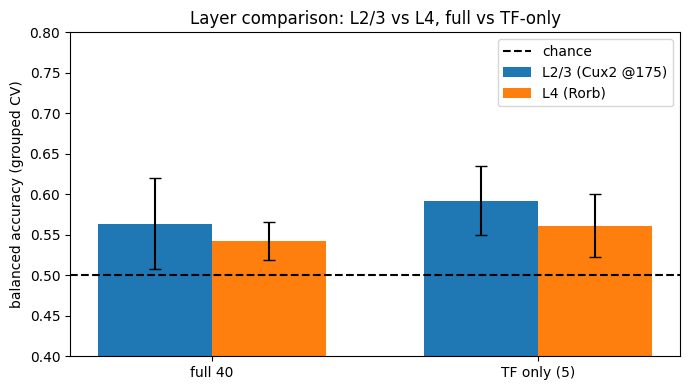

In [54]:
# --- Section 10: run BOTH feature sets on the L4 cohort, compare to L2/3 ---
assert n_splits_l4 >= 2, "Not enough L4 sessions per area for grouped CV (need >=2 per area)."

X40_l4  = tuning_l4.T                                   # (n_cells, 40) full tuning
X_tf_l4 = tuning_l4.T.reshape(-1, 8, 5).mean(axis=1)    # (n_cells, 5) TF only, direction averaged

bal40_l4, auc40_l4 = grouped_cv_eval(X40_l4,  label_l4, groups_l4, n_splits_l4)
baltf_l4, auctf_l4 = grouped_cv_eval(X_tf_l4, label_l4, groups_l4, n_splits_l4)

print(f"[L4   full 40] bal {bal40_l4.mean():.3f} +/- {bal40_l4.std():.3f} | AUC {auc40_l4.mean():.3f}")
print(f"[L4   TF only] bal {baltf_l4.mean():.3f} +/- {baltf_l4.std():.3f} | AUC {auctf_l4.mean():.3f}")
print(f"[L2/3 full 40] bal {bal40.mean():.3f} | AUC {auc40.mean():.3f}   (earlier sections)")
print(f"[L2/3 TF only] bal {bal_tf.mean():.3f} | AUC {auc_tf.mean():.3f}   (Section 9)")

x, w = np.arange(2), 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, [bal40.mean(),    bal_tf.mean()],   w, yerr=[bal40.std(),    bal_tf.std()],   capsize=4, label="L2/3 (Cux2 @175)")
plt.bar(x + w/2, [bal40_l4.mean(), baltf_l4.mean()], w, yerr=[bal40_l4.std(), baltf_l4.std()], capsize=4, label="L4 (Rorb)")
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, ["full 40", "TF only (5)"]); plt.ylim(0.4, 0.8)
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Layer comparison: L2/3 vs L4, full vs TF-only"); plt.legend()
plt.tight_layout(); plt.show()

## 12. Cleaner neurons: filter by responsiveness, re-run TF-only

The TF-only decoder plateaus around 0.59, partly because many neurons barely respond to gratings and just add noise. Here we keep only the most **responsive** neurons and re-run the same TF-only decoder.

The responsiveness score is each neuron's **peak blank-subtracted response** across the 40 drifting conditions (`tuning.max(axis=0)`). Crucially it is **label-agnostic** - it never looks at the AL/PM label - so applying it before the session-grouped CV is *not* leakage. We sweep the keep-fraction (from all neurons down to the top 10%) and watch balanced accuracy.

**Caveat:** filtering changes the population, so a higher number here means "accuracy on well-driven neurons", not a free improvement on the full population.

keep 100.0% (gOSI>=p0): n=1747 | bal 0.592 +/- 0.043
keep  75.0% (gOSI>=p25): n=1310 | bal 0.599 +/- 0.050
keep  50.0% (gOSI>=p50): n= 874 | bal 0.613 +/- 0.029
keep  25.0% (gOSI>=p75): n= 437 | bal 0.644 +/- 0.071
keep  10.0% (gOSI>=p90): n= 175 | bal 0.598 +/- 0.077


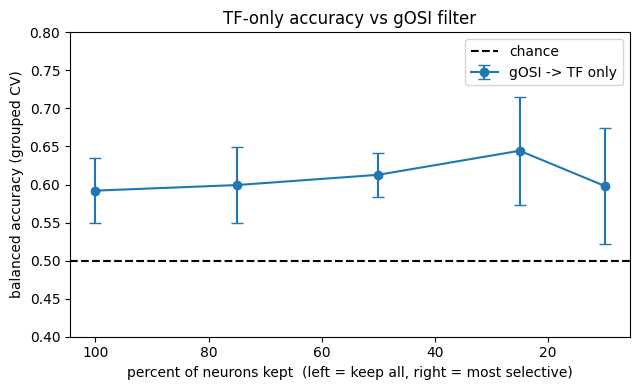


BEST: gOSI keeping top ~25% of neurons (n=437) -> balanced acc 0.644 +/- 0.071
caveat: optimistic max (threshold chosen on the same CV score).


In [55]:
# --- Section 12: filter neurons by orientation selectivity (gOSI), re-run the TF-only decoder ---
# gOSI is label-agnostic (never uses AL/PM), so filtering before grouped CV is NOT leakage.
dir_curve = np.clip(tuning.T.reshape(-1, 8, 5), 0, None).mean(axis=2)  # (n_cells, 8) response vs direction
th    = np.deg2rad(orivals)                       # 8 directions in radians
den   = dir_curve.sum(axis=1) + 1e-9
score = np.abs(dir_curve @ np.exp(2j * th)) / den # gOSI (0..1); use 1j for gDSI
score_name = "gOSI"

qs = [0, 25, 50, 75, 90]                          # 0 keeps all; larger q keeps the most selective
kept_pct, accs, errs = [], [], []
best = (None, -1.0, 0.0, 0)                        # (q, acc, std, n) of the best keep-fraction
for q in qs:
    mask = score >= np.percentile(score, q)
    gp, lp = groups[mask], label[mask]
    ns_q = min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))
    kept_pct.append(100 * mask.mean())
    if ns_q < 2 or mask.sum() < 10:               # not enough sessions/neurons per area
        accs.append(np.nan); errs.append(0.0)
        print(f"keep {100*mask.mean():5.1f}% ({score_name}>=p{q}): n={int(mask.sum()):4d} | skipped"); continue
    b, _ = grouped_cv_eval(X_tf[mask], lp, gp, ns_q)
    accs.append(b.mean()); errs.append(b.std())
    if b.mean() > best[1]:
        best = (q, b.mean(), b.std(), int(mask.sum()))
    print(f"keep {100*mask.mean():5.1f}% ({score_name}>=p{q}): n={int(mask.sum()):4d} | bal {b.mean():.3f} +/- {b.std():.3f}")

plt.figure(figsize=(6.5, 4))
plt.errorbar(kept_pct, accs, yerr=errs, marker="o", capsize=4, label=f"{score_name} -> TF only")
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xlabel("percent of neurons kept  (left = keep all, right = most selective)")
plt.ylabel("balanced accuracy (grouped CV)")
plt.title(f"TF-only accuracy vs {score_name} filter"); plt.ylim(0.4, 0.8)
plt.gca().invert_xaxis(); plt.legend(); plt.tight_layout(); plt.show()

q, acc, sd, n = best                               # simplest summary: the best keep-fraction
print(f"\nBEST: {score_name} keeping top ~{100 - q}% of neurons (n={n}) -> balanced acc {acc:.3f} +/- {sd:.3f}")
print("caveat: optimistic max (threshold chosen on the same CV score).")

## 14. Select TF-tuned neurons first, then classify on the TF feature

Following our advisor's point: rather than decoding *every* neuron (many barely modulate and just add noise), first keep only neurons genuinely **tuned to temporal frequency**, then classify those. We judge tuning by a **relative-change threshold** - a per-neuron modulation depth across the 5 TFs:

`depth = (R_max - R_min) / R_max`   (0 if the neuron is not positively driven)

computed from each neuron's TF curve (the 8-direction average). We keep neurons with depth above a threshold, applied **within both areas** and **label-agnostic** (it never looks at AL vs PM, so it is denoising, not leakage - same rationale as the Section 12 filter), then classify the kept neurons on the **5 TF features**.

We sweep the threshold on a fine grid (`t=0` = all neurons) and **auto-report the best point**. **Caveat:** filtering shrinks N, so read a higher point as "accuracy among well-tuned neurons", not a free gain - and the best swept point is optimistic (threshold chosen on the same CV score; the honest version is the Section 17 nested CV).

TF-tuned t>=0.00: n=1747 | bal 0.592 +/- 0.043
TF-tuned t>=0.05: n=1322 | bal 0.596 +/- 0.058
TF-tuned t>=0.10: n=1322 | bal 0.596 +/- 0.058
TF-tuned t>=0.15: n=1322 | bal 0.596 +/- 0.058
TF-tuned t>=0.20: n=1321 | bal 0.596 +/- 0.058
TF-tuned t>=0.25: n=1317 | bal 0.595 +/- 0.057
TF-tuned t>=0.30: n=1307 | bal 0.595 +/- 0.057
TF-tuned t>=0.35: n=1285 | bal 0.596 +/- 0.063
TF-tuned t>=0.40: n=1269 | bal 0.594 +/- 0.064
TF-tuned t>=0.45: n=1245 | bal 0.592 +/- 0.055
TF-tuned t>=0.50: n=1214 | bal 0.602 +/- 0.060
TF-tuned t>=0.55: n=1177 | bal 0.594 +/- 0.072
TF-tuned t>=0.60: n=1132 | bal 0.577 +/- 0.077
TF-tuned t>=0.65: n=1088 | bal 0.581 +/- 0.058
TF-tuned t>=0.70: n=1028 | bal 0.577 +/- 0.067
TF-tuned t>=0.75: n= 977 | bal 0.564 +/- 0.055


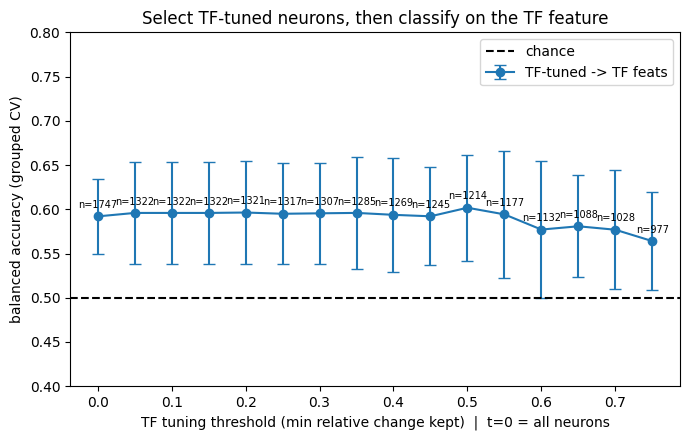


BEST: TF-tuned t>=0.50 (n=1214) -> balanced acc 0.602 +/- 0.060
caveat: optimistic max (threshold chosen on the same CV score).


In [56]:
# --- Section 14: select TF-tuned neurons, then classify on the TF feature ---
# Per-neuron TF curve (label-agnostic): how each neuron responds across the 5 TFs.
tf_curves = tuning.T.reshape(-1, 8, 5).mean(axis=1)   # (n_cells, 5) avg over directions
hi = tf_curves.max(axis=1); lo = tf_curves.min(axis=1)
depth_tf = np.where(hi > 0, (hi - lo) / hi, 0.0)      # TF modulation depth; 0 if not positively driven

def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

thresholds = np.round(np.arange(0.0, 0.76, 0.05), 2)  # fine sweep; t=0 = all neurons
accs, errs, ns_kept = [], [], []
best = (None, -1.0, 0.0, 0)                            # (threshold, acc, std, n) of the best point
for t in thresholds:
    mask = depth_tf >= t
    gp, lp = groups[mask], label[mask]
    ns = nsplits_for(lp, gp); ns_kept.append(int(mask.sum()))
    if ns < 2 or mask.sum() < 10:                     # need enough sessions/neurons to be meaningful
        accs.append(np.nan); errs.append(0.0)
        print(f"TF-tuned t>={t:.2f}: n={int(mask.sum()):4d} | skipped"); continue
    b, _ = grouped_cv_eval(tf_curves[mask], lp, gp, ns)
    accs.append(b.mean()); errs.append(b.std())
    if b.mean() > best[1]:
        best = (t, b.mean(), b.std(), int(mask.sum()))
    print(f"TF-tuned t>={t:.2f}: n={int(mask.sum()):4d} | bal {b.mean():.3f} +/- {b.std():.3f}")

plt.figure(figsize=(7, 4.5))
plt.errorbar(thresholds, accs, yerr=errs, marker="o", capsize=4, label="TF-tuned -> TF feats")
plt.axhline(0.5, ls="--", color="k", label="chance")
for t, a, n in zip(thresholds, accs, ns_kept):
    if np.isfinite(a):
        plt.annotate(f"n={n}", (t, a), textcoords="offset points", xytext=(0, 6), fontsize=7, ha="center")
plt.xlabel("TF tuning threshold (min relative change kept)  |  t=0 = all neurons")
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Select TF-tuned neurons, then classify on the TF feature")
plt.ylim(0.4, 0.8); plt.legend(); plt.tight_layout(); plt.show()

t, acc, sd, n = best                                   # simplest summary: the best threshold
print(f"\nBEST: TF-tuned t>={t:.2f} (n={n}) -> balanced acc {acc:.3f} +/- {sd:.3f}")
print("caveat: optimistic max (threshold chosen on the same CV score).")

In [57]:
# --- Section 19: trial-level tuned-neuron selection (from dff-derived trial_response) ---
# "Tuned" = response changes a lot across a feature's levels (relative change / modulation depth)
# AND that change is reliable across trials (one-way ANOVA). Both come from trial_response
# (per-trial mean dF/F, straight from dff) - not the fully averaged tuning. Built in the SAME
# session order as build_area so it aligns with label / groups.
from scipy.stats import f_oneway
import warnings

def tuned_metrics_for_session(sid):
    _, stim_table, trial_response, _ = compute_tuning(sid)
    tr  = trial_response.astype(float).values                     # (n_trials, n_cells)
    ori = stim_table.orientation.values
    tf  = stim_table.temporal_frequency.values
    def depth_and_p(colvals):
        levels = np.unique(colvals[np.isfinite(colvals)])         # drops blank/NaN trials
        blocks = [tr[colvals == lv] for lv in levels]             # trials grouped by level
        means  = np.vstack([b.mean(axis=0) for b in blocks])      # (n_levels, n_cells)
        mx, mn = means.max(axis=0), means.min(axis=0)
        depth  = np.where(mx > 0, (mx - mn) / mx, 0.0)            # relative change (the 25-50% idea)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                       # constant groups -> nan p
            p = f_oneway(*blocks).pvalue                          # reliability across trials
        return depth, np.nan_to_num(p, nan=1.0)
    d_tf,  p_tf  = depth_and_p(tf)
    d_ori, p_ori = depth_and_p(ori)
    return d_tf, p_tf, d_ori, p_ori

def build_tuned(exps):
    out = [tuned_metrics_for_session(s) for s in exps.id]
    return [np.concatenate(x) for x in zip(*out)]                 # 4 arrays, each (n_cells_area,)

dtf_pm, ptf_pm, dori_pm, pori_pm = build_tuned(exps_pm)
dtf_al, ptf_al, dori_al, pori_al = build_tuned(exps_al)
depth_tf_tr  = np.concatenate([dtf_pm,  dtf_al]);  p_tf_tr  = np.concatenate([ptf_pm,  ptf_al])
depth_ori_tr = np.concatenate([dori_pm, dori_al]); p_ori_tr = np.concatenate([pori_pm, pori_al])

DEPTH_T, ALPHA = 0.25, 0.05                                       # >=25% relative change AND reliable
tuned_tf  = (depth_tf_tr  >= DEPTH_T) & (p_tf_tr  < ALPHA)
tuned_ori = (depth_ori_tr >= DEPTH_T) & (p_ori_tr < ALPHA)
for nm, mask in [("TF", tuned_tf), ("orientation", tuned_ori)]:
    print(f"{nm:11s}-tuned: {int(mask.sum()):4d}/{mask.size} neurons "
          f"(PM {int(mask[label==0].sum())}, AL {int(mask[label==1].sum())})")

Number of cells:  94
Number of cells:  90
Number of cells:  112
Number of cells:  70
Number of cells:  124
Number of cells:  167
Number of cells:  84
Number of cells:  106
Number of cells:  101
Number of cells:  76
Number of cells:  47
Number of cells:  119
Number of cells:  159
Number of cells:  181
Number of cells:  217
TF         -tuned:  860/1747 neurons (PM 479, AL 381)
orientation-tuned: 1050/1747 neurons (PM 515, AL 535)


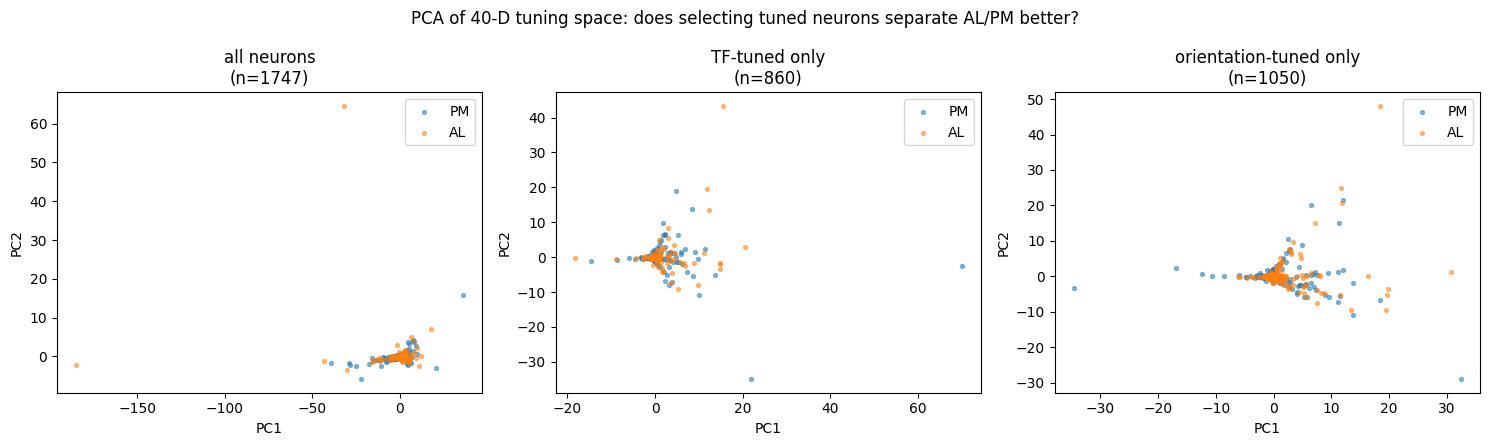

In [58]:
# --- Section 19: PCA of the 40-D tuning space - all vs tuned-only, coloured by area ---
from sklearn.preprocessing import StandardScaler
cols = {0: "tab:blue", 1: "tab:orange"}; nms = {0: "PM", 1: "AL"}

def pca_panel(ax, mask, title):
    if mask.sum() < 5:
        ax.set_title(title + "\n(too few)"); return
    Xz  = StandardScaler().fit_transform(tuning.T[mask])          # standardize the 40 features
    pcs = PCA(n_components=2).fit_transform(Xz)
    lab = label[mask]
    for cval in (0, 1):
        m = lab == cval
        ax.scatter(pcs[m, 0], pcs[m, 1], s=8, alpha=0.5, color=cols[cval], label=nms[cval])
    ax.set_title(f"{title}\n(n={int(mask.sum())})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()

all_mask = np.ones(len(label), bool)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pca_panel(axes[0], all_mask,  "all neurons")
pca_panel(axes[1], tuned_tf,  "TF-tuned only")
pca_panel(axes[2], tuned_ori, "orientation-tuned only")
plt.suptitle("PCA of 40-D tuning space: does selecting tuned neurons separate AL/PM better?")
plt.tight_layout(); plt.show()

TF: all          n=1747 | LogReg 0.512 LDA 0.515 RandomForest 0.561
TF: TF-tuned     n= 860 | LogReg 0.534 LDA 0.535 RandomForest 0.555
DIR: all         n=1747 | LogReg 0.515 LDA 0.516 RandomForest 0.551
DIR: ori-tuned   n=1050 | LogReg 0.488 LDA 0.488 RandomForest 0.553


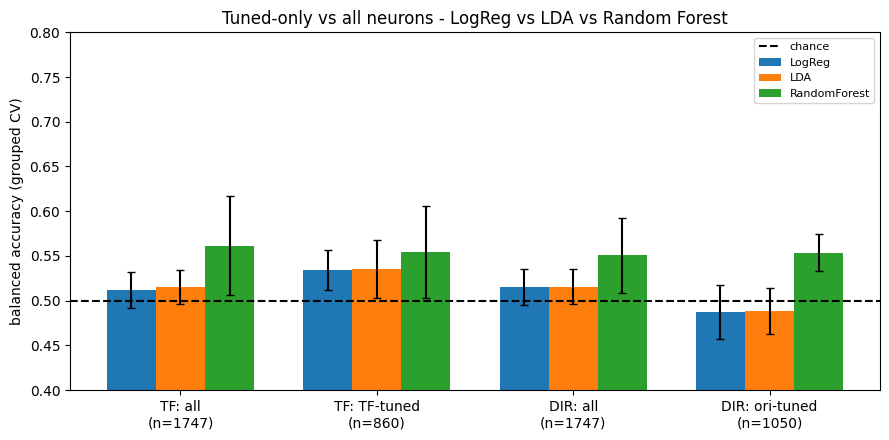

In [59]:
# --- Section 19b: decode tuned subsets vs all neurons - LogReg vs LDA vs Random Forest ---
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

dir_curves = tuning.T.reshape(-1, 8, 5).mean(axis=2)   # (n_cells, 8) direction features
tf_curves  = tuning.T.reshape(-1, 8, 5).mean(axis=1)   # (n_cells, 5) TF features

def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

def grouped_cv_model(clf, X, y, groups, ns, seed=0):
    """Any sklearn estimator on the SAME balanced session-grouped folds as grouped_cv_eval."""
    X = X.reshape(len(X), -1)
    fold = balanced_group_folds(y, groups, ns, seed)
    bals = []
    for k in range(ns):
        tr, va = fold != k, fold == k
        if len(np.unique(y[va])) < 2 or len(np.unique(y[tr])) < 2:
            continue
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clone(clf))])
        pipe.fit(X[tr], y[tr])
        bals.append(balanced_accuracy_score(y[va], pipe.predict(X[va])))
    return (float(np.mean(bals)), float(np.std(bals))) if bals else (np.nan, 0.0)

models = {
    "LogReg":       LogisticRegression(max_iter=5000),
    "LDA":          LinearDiscriminantAnalysis(),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0),
}

all_mask = np.ones(len(label), bool)
rows = [
    ("TF: all",        tf_curves,  all_mask),
    ("TF: TF-tuned",   tf_curves,  tuned_tf),
    ("DIR: all",       dir_curves, all_mask),
    ("DIR: ori-tuned", dir_curves, tuned_ori),
]

results = {m: [] for m in models}; errs = {m: [] for m in models}; names = []
for name, X, mask in rows:
    gp, lp = groups[mask], label[mask]; ns = nsplits_for(lp, gp)
    names.append(f"{name}\n(n={int(mask.sum())})")
    line = f"{name:16s} n={int(mask.sum()):4d} |"
    for m, clf in models.items():
        mean, sd = (np.nan, 0.0) if (ns < 2 or mask.sum() < 10) else grouped_cv_model(clf, X[mask], lp, gp, ns)
        results[m].append(mean); errs[m].append(sd)
        line += f" {m} {mean:.3f}" if np.isfinite(mean) else f" {m}  -  "
    print(line)

x = np.arange(len(rows)); w = 0.25
plt.figure(figsize=(9, 4.5))
for i, m in enumerate(models):
    plt.bar(x + (i - 1) * w, results[m], w, yerr=errs[m], capsize=3, label=m)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, names); plt.ylim(0.4, 0.8)
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Tuned-only vs all neurons - LogReg vs LDA vs Random Forest")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 13. Cux2 layer 4 (@275) and combining layers 2/3 + 4

Section 10 reached "layer 4" by switching to `Rorb-IRES2-Cre`, which mixes layer with genotype. `Cux2-CreERT2` actually labels both L2/3 and L4, so here we stay on the **same line** and only change depth: `imaging_depths=[275]` gives L4. That makes the L2/3-vs-L4 comparison clean (depth is the only difference).

We then build a **combined L2/3 + L4** cohort (simply more neurons) and classify AL vs PM in all three cohorts - L2/3 (175), L4 (275), and combined - with **both** feature sets (full-40 tuning and TF-only). The question: does L4 look different from L2/3, and does adding more neurons (the combined cohort) raise accuracy?

In [60]:
# --- Section 13: Cux2 layer 4 (@275) + combined L2/3+L4 datasets ---
# standalone-safe: define builders here if the Section 2/3 cells were not run
if "compute_tuning" not in globals():
    def compute_tuning(session_id):
        data_set = boc.get_ophys_experiment_data(session_id)
        _, dff = data_set.get_dff_traces(); number_cells = dff.shape[0]
        stim_table = data_set.get_stimulus_table('drifting_gratings')
        orivals = np.unique(stim_table.orientation); orivals = orivals[np.isfinite(orivals)]
        tfvals  = np.unique(stim_table.temporal_frequency); tfvals = tfvals[np.isfinite(tfvals)]
        trial_response = pd.DataFrame(index=stim_table.index.values,
                                      columns=np.array(range(number_cells)).astype(str))
        for ind, row in stim_table.iterrows():
            for nc in range(number_cells):
                trial_response.loc[ind, str(nc)] = dff[nc, int(row.start):int(row.end)].mean()
        blank_response = trial_response[np.isnan(stim_table.orientation)].mean()
        tuning_array = np.empty((8, 5, number_cells))
        for i, tf in enumerate(tfvals):
            for j, ori in enumerate(orivals):
                sel = (stim_table.orientation == ori) & (stim_table.temporal_frequency == tf)
                tuning_array[j, i, :] = trial_response[sel].mean() - blank_response
        return dff, stim_table, trial_response, tuning_array

if "build_area" not in globals():
    def build_area(exps, verbose=False):
        vecs, sess = [], []
        for sid in exps.id:
            _, _, _, ta = compute_tuning(sid)
            flat = ta.reshape(-1, ta.shape[-1]); vecs.append(flat); sess.extend([sid] * flat.shape[1])
        return np.hstack(vecs), np.array(sess)

common_l4c = dict(cre_lines=['Cux2-CreERT2'], imaging_depths=[275], stimuli=['drifting_gratings'])
exps_pm_l4c = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_l4c))
exps_al_l4c = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_l4c))
print(f"Cux2 L4 (@275) VISpm sessions: {len(exps_pm_l4c)} | VISal sessions: {len(exps_al_l4c)}")
if len(exps_pm_l4c) == 0 or len(exps_al_l4c) == 0:
    raise ValueError("No Cux2 L4 @275 sessions for one area - try a different depth (e.g. 265/300).")

tuning_pm_l4c, session_pm_l4c = build_area(exps_pm_l4c)
tuning_al_l4c, session_al_l4c = build_area(exps_al_l4c)
label_l4c  = np.append(np.repeat(0, tuning_pm_l4c.shape[1]), np.repeat(1, tuning_al_l4c.shape[1]))
tuning_l4c = np.append(tuning_pm_l4c, tuning_al_l4c, axis=1)          # (40, n_L4)
groups_l4c = np.concatenate([session_pm_l4c, session_al_l4c])

# combined = existing L2/3 (tuning/label/groups) + L4; session ids are distinct, so groups stays valid
tuning_comb = np.append(tuning, tuning_l4c, axis=1)
label_comb  = np.append(label, label_l4c)
groups_comb = np.concatenate([groups, groups_l4c])
print("cells -> L2/3:", tuning.shape[1], "| L4:", tuning_l4c.shape[1], "| combined:", tuning_comb.shape[1])

Cux2 L4 (@275) VISpm sessions: 4 | VISal sessions: 6
Number of cells:  231
Number of cells:  85
Number of cells:  128
Number of cells:  232
Number of cells:  240
Number of cells:  202
Number of cells:  162
Number of cells:  168
Number of cells:  207
Number of cells:  286
cells -> L2/3: 1747 | L4: 1941 | combined: 3688


In [61]:
import pandas as pd

exps  = pd.DataFrame(boc.get_ophys_experiments())
cells = pd.DataFrame(boc.get_cell_specimens())

# cell-specimens uses 'tld1_name' for the driver/Cre line, and already has 'imaging_depth'
cre_col = "cre_line" if "cre_line" in cells.columns else "tld1_name"
cells = cells.rename(columns={cre_col: "cre_line"})

# sessions / containers per (cre_line, depth)
sess_tbl = (exps.groupby(["cre_line", "imaging_depth"])
                 .agg(n_sessions=("id", "nunique"),
                      n_containers=("experiment_container_id", "nunique"))
                 .reset_index())

# neurons per (cre_line, depth)  -- no merge needed, avoids the column collision
cell_tbl = (cells.groupby(["cre_line", "imaging_depth"])
                  .agg(n_neurons=("cell_specimen_id", "nunique"))
                  .reset_index())

summary = (sess_tbl.merge(cell_tbl, on=["cre_line", "imaging_depth"], how="outer")
                    .sort_values(["cre_line", "imaging_depth"])
                    .reset_index(drop=True))
summary["n_neurons"] = summary["n_neurons"].fillna(0).astype(int)
print(summary.to_string(index=False))

         cre_line  imaging_depth  n_sessions  n_containers  n_neurons
     Cux2-CreERT2            175         120            40       7582
     Cux2-CreERT2            275         105            35       8988
     Cux2-CreERT2            276           3             1        212
    Emx1-IRES-Cre            175          51            17       4234
    Emx1-IRES-Cre            265           3             1        346
    Emx1-IRES-Cre            275          39            13       4530
    Emx1-IRES-Cre            365           3             1        162
    Emx1-IRES-Cre            375          27             9       1989
      Fezf2-CreER            375          15             5        901
      Fezf2-CreER            390           3             1        109
      Fezf2-CreER            400           9             3        378
        Nr5a1-Cre            300           6             2        101
        Nr5a1-Cre            320           3             1          5
        Nr5a1-Cre   

L2/3 (175): n=1747 | full40 0.564+/-0.057 | TF-only 0.592+/-0.043
L4 (275): n=1941 | full40 0.586+/-0.072 | TF-only 0.667+/-0.080
L2/3+L4: n=3688 | full40 0.562+/-0.047 | TF-only 0.606+/-0.045


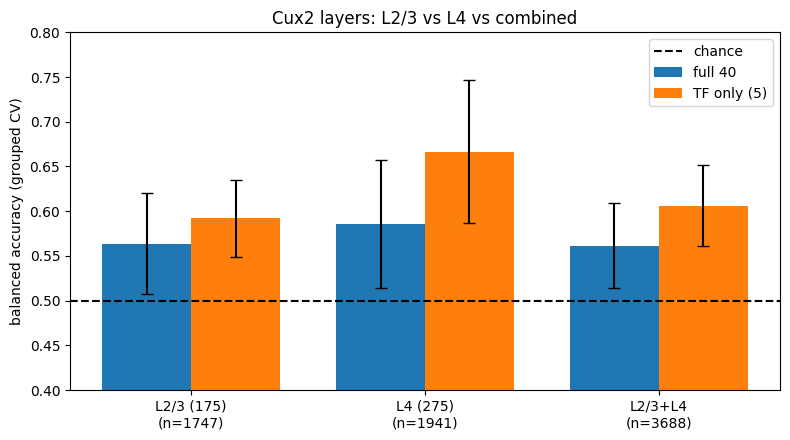

In [62]:
# --- Section 13: full-40 vs TF-only across L2/3, L4, combined ---
def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

cohorts = [
    ("L2/3 (175)", tuning,      label,      groups),
    ("L4 (275)",   tuning_l4c,  label_l4c,  groups_l4c),
    ("L2/3+L4",    tuning_comb, label_comb, groups_comb),
]
res_full, err_full, res_tf, err_tf, names = [], [], [], [], []
for name, tun, lab, grp in cohorts:
    ns = nsplits_for(lab, grp)
    names.append(f"{name}\n(n={tun.shape[1]})")
    if ns < 2:
        res_full.append(np.nan); err_full.append(0); res_tf.append(np.nan); err_tf.append(0)
        print(f"{name}: skipped (n_splits<2)"); continue
    b40, _ = grouped_cv_eval(tun.T, lab, grp, ns)
    btf, _ = grouped_cv_eval(tun.T.reshape(-1, 8, 5).mean(axis=1), lab, grp, ns)
    res_full.append(b40.mean()); err_full.append(b40.std())
    res_tf.append(btf.mean());   err_tf.append(btf.std())
    print(f"{name}: n={tun.shape[1]:4d} | full40 {b40.mean():.3f}+/-{b40.std():.3f} | TF-only {btf.mean():.3f}+/-{btf.std():.3f}")

x, w = np.arange(len(cohorts)), 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(x - w/2, res_full, w, yerr=err_full, capsize=4, label="full 40")
plt.bar(x + w/2, res_tf,   w, yerr=err_tf,   capsize=4, label="TF only (5)")
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, names); plt.ylim(0.4, 0.8)
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Cux2 layers: L2/3 vs L4 vs combined"); plt.legend()
plt.tight_layout(); plt.show()

In [63]:
# --- Section 13: Cux2 layer 4 (@275) + combined L2/3+L4 datasets ---
# standalone-safe: define builders here if the Section 2/3 cells were not run
if "compute_tuning" not in globals():
    def compute_tuning(session_id):
        data_set = boc.get_ophys_experiment_data(session_id)
        _, dff = data_set.get_dff_traces(); number_cells = dff.shape[0]
        stim_table = data_set.get_stimulus_table('drifting_gratings')
        orivals = np.unique(stim_table.orientation); orivals = orivals[np.isfinite(orivals)]
        tfvals  = np.unique(stim_table.temporal_frequency); tfvals = tfvals[np.isfinite(tfvals)]
        trial_response = pd.DataFrame(index=stim_table.index.values,
                                      columns=np.array(range(number_cells)).astype(str))
        for ind, row in stim_table.iterrows():
            for nc in range(number_cells):
                trial_response.loc[ind, str(nc)] = dff[nc, int(row.start):int(row.end)].mean()
        blank_response = trial_response[np.isnan(stim_table.orientation)].mean()
        tuning_array = np.empty((8, 5, number_cells))
        for i, tf in enumerate(tfvals):
            for j, ori in enumerate(orivals):
                sel = (stim_table.orientation == ori) & (stim_table.temporal_frequency == tf)
                tuning_array[j, i, :] = trial_response[sel].mean() - blank_response
        return dff, stim_table, trial_response, tuning_array

if "build_area" not in globals():
    def build_area(exps, verbose=False):
        vecs, sess = [], []
        for sid in exps.id:
            _, _, _, ta = compute_tuning(sid)
            flat = ta.reshape(-1, ta.shape[-1]); vecs.append(flat); sess.extend([sid] * flat.shape[1])
        return np.hstack(vecs), np.array(sess)

common_l4c = dict(cre_lines=['Cux2-CreERT2'], imaging_depths=[275], stimuli=['drifting_gratings'])
exps_pm_l4c = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_l4c))
exps_al_l4c = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_l4c))
print(f"Cux2 L4 (@275) VISpm sessions: {len(exps_pm_l4c)} | VISal sessions: {len(exps_al_l4c)}")
if len(exps_pm_l4c) == 0 or len(exps_al_l4c) == 0:
    raise ValueError("No Cux2 L4 @275 sessions for one area - try a different depth (e.g. 265/300).")

tuning_pm_l4c, session_pm_l4c = build_area(exps_pm_l4c)
tuning_al_l4c, session_al_l4c = build_area(exps_al_l4c)
label_l4c  = np.append(np.repeat(0, tuning_pm_l4c.shape[1]), np.repeat(1, tuning_al_l4c.shape[1]))
tuning_l4c = np.append(tuning_pm_l4c, tuning_al_l4c, axis=1)          # (40, n_L4)
groups_l4c = np.concatenate([session_pm_l4c, session_al_l4c])

# combined = existing L2/3 (tuning/label/groups) + L4; session ids are distinct, so groups stays valid
tuning_comb = np.append(tuning, tuning_l4c, axis=1)
label_comb  = np.append(label, label_l4c)
groups_comb = np.concatenate([groups, groups_l4c])
print("cells -> L2/3:", tuning.shape[1], "| L4:", tuning_l4c.shape[1], "| combined:", tuning_comb.shape[1])

# all depths: SAME Cux2 line + drifting, but NO imaging_depths filter -> every available depth
common_all = dict(cre_lines=['Cux2-CreERT2'], stimuli=['drifting_gratings'])
exps_pm_all = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_all))
exps_al_all = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_all))
print(f"Cux2 all-depths VISpm sessions: {len(exps_pm_all)} | VISal sessions: {len(exps_al_all)}"
      f" | depths: {sorted(pd.concat([exps_pm_all, exps_al_all]).imaging_depth.unique())}")
tuning_pm_all, session_pm_all = build_area(exps_pm_all)
tuning_al_all, session_al_all = build_area(exps_al_all)
label_all  = np.append(np.repeat(0, tuning_pm_all.shape[1]), np.repeat(1, tuning_al_all.shape[1]))
tuning_all = np.append(tuning_pm_all, tuning_al_all, axis=1)         # (40, n_all_depths)
groups_all = np.concatenate([session_pm_all, session_al_all])
print("all-depths cells:", tuning_all.shape[1])

Cux2 L4 (@275) VISpm sessions: 4 | VISal sessions: 6
Number of cells:  231
Number of cells:  85
Number of cells:  128
Number of cells:  232
Number of cells:  240
Number of cells:  202
Number of cells:  162
Number of cells:  168
Number of cells:  207
Number of cells:  286
cells -> L2/3: 1747 | L4: 1941 | combined: 3688
Cux2 all-depths VISpm sessions: 13 | VISal sessions: 13 | depths: [175, 275, 276]
Number of cells:  94
Number of cells:  90
Number of cells:  231
Number of cells:  112
Number of cells:  85
Number of cells:  70
Number of cells:  128
Number of cells:  124
Number of cells:  167
Number of cells:  84
Number of cells:  106
Number of cells:  232
Number of cells:  101
Number of cells:  240
Number of cells:  76
Number of cells:  202
Number of cells:  162
Number of cells:  168
Number of cells:  47
Number of cells:  119
Number of cells:  207
Number of cells:  159
Number of cells:  181
Number of cells:  286
Number of cells:  155
Number of cells:  217
all-depths cells: 3843


In [ ]:
# --- Section 13: full-40 vs TF-only across L2/3, L4, combined ---
def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

cohorts = [
    ("L2/3 (175)", tuning,      label,      groups),
    ("L4 (275)",   tuning_l4c,  label_l4c,  groups_l4c),
    # ("L2/3+L4",    tuning_comb, label_comb, groups_comb),
    # ("all depths", tuning_all,  label_all,  groups_all),
]
res_full, err_full, res_tf, err_tf, names = [], [], [], [], []
for name, tun, lab, grp in cohorts:
    ns = nsplits_for(lab, grp)
    names.append(f"{name}\n(n={tun.shape[1]}; PM {int((lab == 0).sum())}, AL {int((lab == 1).sum())})")
    if ns < 2:
        res_full.append(np.nan); err_full.append(0); res_tf.append(np.nan); err_tf.append(0)
        print(f"{name}: skipped (n_splits<2)"); continue
    b40, _ = grouped_cv_eval(tun.T, lab, grp, ns)
    btf, _ = grouped_cv_eval(tun.T.reshape(-1, 8, 5).mean(axis=1), lab, grp, ns)
    res_full.append(b40.mean()); err_full.append(b40.std())
    res_tf.append(btf.mean());   err_tf.append(btf.std())
    print(f"{name}: n={tun.shape[1]:4d} | full40 {b40.mean():.3f}+/-{b40.std():.3f} | TF-only {btf.mean():.3f}+/-{btf.std():.3f}")

x, w = np.arange(len(cohorts)), 0.38
plt.figure(figsize=(9.5, 4.5))
plt.bar(x - w/2, res_full, w, yerr=err_full, capsize=4, label="full 40")
plt.bar(x + w/2, res_tf,   w, yerr=err_tf,   capsize=4, label="TF only (5)")
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, names); plt.ylim(0.4, 0.8)
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Cux2 layers: L2/3 vs L4 vs combined vs all depths"); plt.legend()
plt.tight_layout(); plt.show()

In [65]:
# --- Section 19: trial-level tuned-neuron selection (from dff-derived trial_response) ---
# "Tuned" = response changes a lot across a feature's levels (relative change / modulation depth)
# AND that change is reliable across trials (one-way ANOVA). Both come from trial_response
# (per-trial mean dF/F, straight from dff) - not the fully averaged tuning. Built in the SAME
# session order as build_area so it aligns with label / groups.
from scipy.stats import f_oneway
import warnings

def tuned_metrics_for_session(sid):
    _, stim_table, trial_response, _ = compute_tuning(sid)
    tr  = trial_response.astype(float).values                     # (n_trials, n_cells)
    ori = stim_table.orientation.values
    tf  = stim_table.temporal_frequency.values
    def depth_and_p(colvals):
        levels = np.unique(colvals[np.isfinite(colvals)])         # drops blank/NaN trials
        blocks = [tr[colvals == lv] for lv in levels]             # trials grouped by level
        means  = np.vstack([b.mean(axis=0) for b in blocks])      # (n_levels, n_cells)
        mx, mn = means.max(axis=0), means.min(axis=0)
        depth  = np.where(mx > 0, (mx - mn) / mx, 0.0)            # relative change (the 25-50% idea)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                       # constant groups -> nan p
            p = f_oneway(*blocks).pvalue                          # reliability across trials
        return depth, np.nan_to_num(p, nan=1.0)
    d_tf,  p_tf  = depth_and_p(tf)
    d_ori, p_ori = depth_and_p(ori)
    return d_tf, p_tf, d_ori, p_ori

def build_tuned(exps):
    out = [tuned_metrics_for_session(s) for s in exps.id]
    return [np.concatenate(x) for x in zip(*out)]                 # 4 arrays, each (n_cells_area,)

dtf_pm, ptf_pm, dori_pm, pori_pm = build_tuned(exps_pm)
dtf_al, ptf_al, dori_al, pori_al = build_tuned(exps_al)
depth_tf_tr  = np.concatenate([dtf_pm,  dtf_al]);  p_tf_tr  = np.concatenate([ptf_pm,  ptf_al])
depth_ori_tr = np.concatenate([dori_pm, dori_al]); p_ori_tr = np.concatenate([pori_pm, pori_al])

DEPTH_T, ALPHA = 0.25, 0.05                                       # >=25% relative change AND reliable
tuned_tf  = (depth_tf_tr  >= DEPTH_T) & (p_tf_tr  < ALPHA)
tuned_ori = (depth_ori_tr >= DEPTH_T) & (p_ori_tr < ALPHA)
for nm, mask in [("TF", tuned_tf), ("orientation", tuned_ori)]:
    print(f"{nm:11s}-tuned: {int(mask.sum()):4d}/{mask.size} neurons "
          f"(PM {int(mask[label==0].sum())}, AL {int(mask[label==1].sum())})")

Number of cells:  94
Number of cells:  90
Number of cells:  112
Number of cells:  70
Number of cells:  124
Number of cells:  167
Number of cells:  84
Number of cells:  106
Number of cells:  101
Number of cells:  76
Number of cells:  47
Number of cells:  119
Number of cells:  159
Number of cells:  181
Number of cells:  217
TF         -tuned:  860/1747 neurons (PM 479, AL 381)
orientation-tuned: 1050/1747 neurons (PM 515, AL 535)


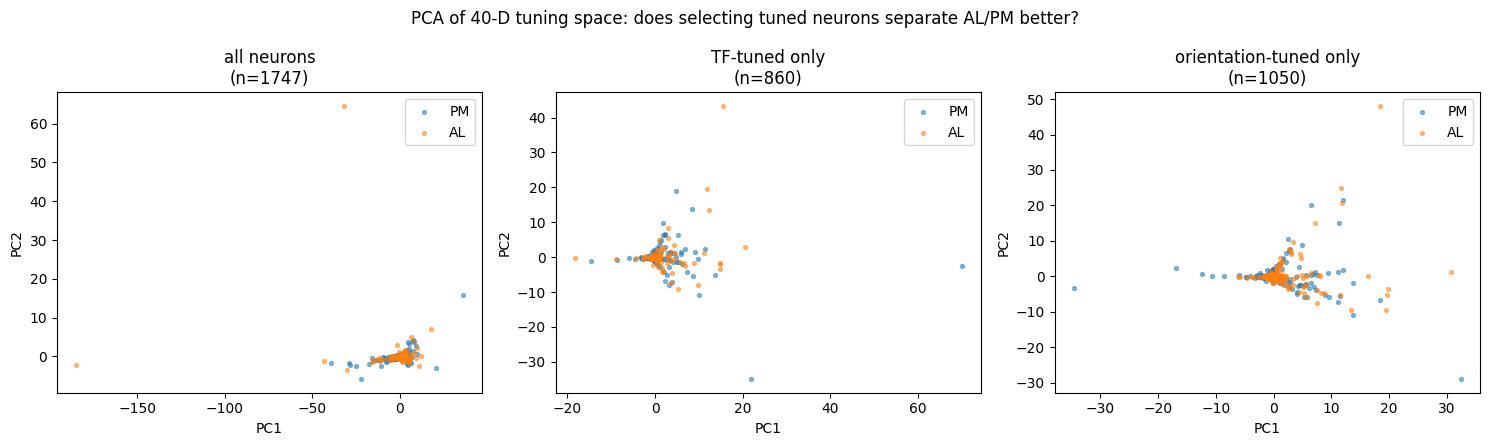

In [66]:
# --- Section 19: PCA of the 40-D tuning space - all vs tuned-only, coloured by area ---
from sklearn.preprocessing import StandardScaler
cols = {0: "tab:blue", 1: "tab:orange"}; nms = {0: "PM", 1: "AL"}

def pca_panel(ax, mask, title):
    if mask.sum() < 5:
        ax.set_title(title + "\n(too few)"); return
    Xz  = StandardScaler().fit_transform(tuning.T[mask])          # standardize the 40 features
    pcs = PCA(n_components=2).fit_transform(Xz)
    lab = label[mask]
    for cval in (0, 1):
        m = lab == cval
        ax.scatter(pcs[m, 0], pcs[m, 1], s=8, alpha=0.5, color=cols[cval], label=nms[cval])
    ax.set_title(f"{title}\n(n={int(mask.sum())})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()

all_mask = np.ones(len(label), bool)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pca_panel(axes[0], all_mask,  "all neurons")
pca_panel(axes[1], tuned_tf,  "TF-tuned only")
pca_panel(axes[2], tuned_ori, "orientation-tuned only")
plt.suptitle("PCA of 40-D tuning space: does selecting tuned neurons separate AL/PM better?")
plt.tight_layout(); plt.show()

TF: all          n=1747 | bal 0.592 +/- 0.043
TF: TF-tuned     n= 860 | bal 0.618 +/- 0.055
DIR: all         n=1747 | bal 0.490 +/- 0.033
DIR: ori-tuned   n=1050 | bal 0.536 +/- 0.056


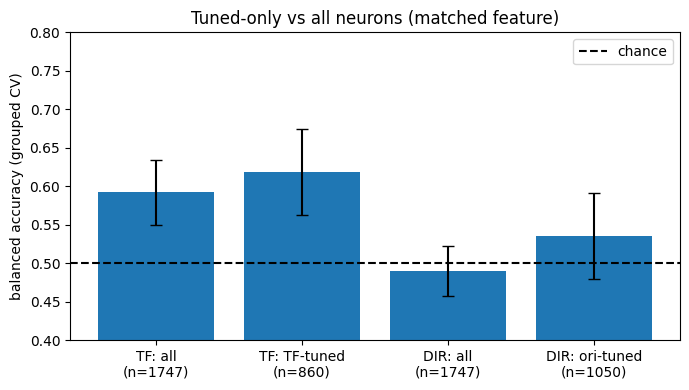

In [67]:
# --- Section 19b: decode accuracy on tuned subsets vs all neurons (matched features) ---
dir_curves = tuning.T.reshape(-1, 8, 5).mean(axis=2)   # (n_cells, 8) direction features
tf_curves  = tuning.T.reshape(-1, 8, 5).mean(axis=1)   # (n_cells, 5) TF features

def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

def eval_subset(X, mask):
    gp, lp = groups[mask], label[mask]
    ns = nsplits_for(lp, gp)
    if ns < 2 or mask.sum() < 10:
        return np.nan, 0.0, int(mask.sum())
    b, _ = grouped_cv_eval(X[mask], lp, gp, ns)
    return b.mean(), b.std(), int(mask.sum())

all_mask = np.ones(len(label), bool)
rows = [
    ("TF: all",        tf_curves,  all_mask),
    ("TF: TF-tuned",   tf_curves,  tuned_tf),
    ("DIR: all",       dir_curves, all_mask),
    ("DIR: ori-tuned", dir_curves, tuned_ori),
]
names, accs, errs = [], [], []
for name, X, mask in rows:
    m, s, n = eval_subset(X, mask)
    names.append(f"{name}\n(n={n})"); accs.append(m); errs.append(s)
    print(f"{name:16s} n={n:4d} | bal {m:.3f} +/- {s:.3f}" if np.isfinite(m) else f"{name:16s}: skipped")

plt.figure(figsize=(7, 4))
plt.bar(names, accs, yerr=errs, capsize=4)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.ylim(0.4, 0.8); plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Tuned-only vs all neurons (matched feature)"); plt.legend()
plt.tight_layout(); plt.show()

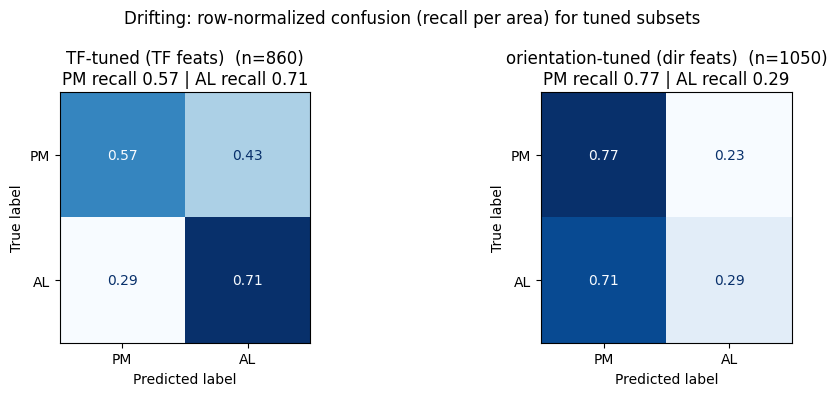

In [68]:
# --- Section 19c: confusion matrices for the drifting TF-tuned and orientation-tuned decoders ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

tf_curves  = tuning.T.reshape(-1, 8, 5).mean(axis=1)   # (n_cells, 5) TF features
dir_curves = tuning.T.reshape(-1, 8, 5).mean(axis=2)   # (n_cells, 8) direction features

def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

panels = [
    ("TF-tuned (TF feats)",           tf_curves,  tuned_tf),
    ("orientation-tuned (dir feats)", dir_curves, tuned_ori),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, X, mask) in zip(axes, panels):
    gp, lp = groups[mask], label[mask]; ns = nsplits_for(lp, gp)
    _, _, y_true, y_pred = grouped_cv_eval(X[mask], lp, gp, ns, return_preds=True)
    cm = confusion_matrix(y_true, y_pred)
    cm_recall = cm / cm.sum(axis=1, keepdims=True)      # row-normalized -> per-area recall
    ConfusionMatrixDisplay(cm_recall, display_labels=["PM", "AL"]).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(f"{name}  (n={int(mask.sum())})\n"
                 f"PM recall {cm_recall[0, 0]:.2f} | AL recall {cm_recall[1, 1]:.2f}")
plt.suptitle("Drifting: row-normalized confusion (recall per area) for tuned subsets")
plt.tight_layout(); plt.show()

## 21. Static gratings: full analysis pipeline

Everything above used `drifting_gratings` (8 directions x 5 temporal frequencies). Here we repeat the **whole analysis pipeline** on the `static_gratings` stimulus, whose grid is `6 orientations x 5 spatial frequencies` (phase-averaged) = **30 features per neuron**. We reuse the dataset built in **Section 11** (`tuning_st`, `label_st`, `groups_st`, `n_splits_st`, and the cohort tables `exps_pm_st` / `exps_al_st`), so **run Section 11 (and the shared helper cells) first**.

We swap **temporal frequency -> spatial frequency (SF)** everywhere and run the same five steps:

- **21a** mean tuning heatmap per area (orientation x SF),
- **21b** population tuning curves (SF and orientation) + preferred-feature distributions,
- **21c** PCA and t-SNE (look before classifying),
- **21d** trial-level tuned-neuron selection (relative change + ANOVA) on SF / orientation,
- **21e** session-grouped cross-validation (full-30 vs SF-only vs orientation-only, all neurons vs tuned).

Why SF matters: the literature says the strongest AL-vs-PM axis is **spatial frequency** (AL prefers low SF, PM high SF) - an axis drifting gratings (single SF) cannot see. Static gratings use orientations 0-150 deg (not directions), so direction selectivity does not apply here.

**Caveat:** drifting and static are recorded in *different sessions* of the same container, so this is a different neuron set (30 feats vs 40) - read it as "does the static stimulus separate the areas", not a matched-neuron comparison.

In [70]:
# --- Section 21.0: build the static-gratings dataset (self-contained) ---
# Same Cux2 @175 (layer 2/3) cohort as the drifting analysis, but stimulus = static_gratings.
# Grid is 6 orientations x 5 spatial frequencies x 4 phases -> phase-averaged to a 6x5 = 30-vector.
common_st  = dict(cre_lines=['Cux2-CreERT2'], imaging_depths=[175], stimuli=['static_gratings'])
exps_pm_st = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_st))
exps_al_st = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_st))
print(f"static VISpm sessions: {len(exps_pm_st)} | static VISal sessions: {len(exps_al_st)}")

def compute_static_tuning(session_id):
    """(6 ori x 5 SF) phase-averaged, blank-subtracted mean dF/F per cell -> (30, ncells)."""
    data_set = boc.get_ophys_experiment_data(session_id)
    _, dff = data_set.get_dff_traces()
    ncells = dff.shape[0]
    stim = data_set.get_stimulus_table("static_gratings")
    orivals = np.unique(stim.orientation.values); orivals = orivals[np.isfinite(orivals)]
    sfvals  = np.unique(stim.spatial_frequency.values); sfvals = sfvals[np.isfinite(sfvals)]
    starts = stim.start.values.astype(int); ends = stim.end.values.astype(int)
    resp = np.empty((len(stim), ncells))
    for t in range(len(stim)):
        resp[t] = dff[:, starts[t]:ends[t]].mean(axis=1)      # mean dF/F per trial, all cells
    ori = stim.orientation.values; sf = stim.spatial_frequency.values
    blank = resp[~np.isfinite(ori)].mean(axis=0)               # blank sweeps (NaN orientation)
    grid = np.zeros((len(orivals), len(sfvals), ncells))
    for j, o in enumerate(orivals):
        for i, s in enumerate(sfvals):
            sel = (ori == o) & (sf == s)                       # averages over the 4 phases
            if sel.any():
                grid[j, i, :] = resp[sel].mean(axis=0) - blank
    return grid.reshape(-1, ncells)                            # (30, ncells), order = ori-major

def build_static(exps):
    vecs, sess = [], []
    for sid in exps.id:
        g = compute_static_tuning(sid)
        vecs.append(g); sess.extend([sid] * g.shape[1])
    return np.hstack(vecs), np.array(sess)

static_pm, session_pm_st = build_static(exps_pm_st)
static_al, session_al_st = build_static(exps_al_st)
label_st    = np.append(np.repeat(0, static_pm.shape[1]), np.repeat(1, static_al.shape[1]))
tuning_st   = np.append(static_pm, static_al, axis=1)          # (30, n_cells_static)
groups_st   = np.concatenate([session_pm_st, session_al_st])
n_splits_st = min(5, len(np.unique(session_pm_st)), len(np.unique(session_al_st)))

# full-30 grouped-CV baseline (reused by 21e for the continuity print)
assert n_splits_st >= 2, "Not enough static-gratings sessions per area for grouped CV (need >=2 per area)."
X_static = tuning_st.T                                         # (n_cells, 30)
bal_st, auc_st = grouped_cv_eval(X_static, label_st, groups_st, n_splits_st)
print("static dataset:", tuning_st.shape, "| PM cells:", int((label_st == 0).sum()),
      "| AL cells:", int((label_st == 1).sum()), "| n_splits:", n_splits_st)
print(f"[static gratings, 30 feats] bal {bal_st.mean():.3f} +/- {bal_st.std():.3f} | AUC {auc_st.mean():.3f}")

static VISpm sessions: 9 | static VISal sessions: 6
static dataset: (30, 1563) | PM cells: 810 | AL cells: 753 | n_splits: 5
[static gratings, 30 feats] bal 0.567 +/- 0.029 | AUC 0.584


In [71]:
# --- Section 21 setup: static axis values + per-neuron SF / orientation curves ---
# Derive the axis values from one session so ticks/reshapes match how compute_static_tuning
# built the grid (np.unique -> ascending): grid[j=orientation, i=spatial_frequency].
_ds  = boc.get_ophys_experiment_data(int(exps_pm_st.id.iloc[0]))
_st  = _ds.get_stimulus_table("static_gratings")
orivals_st = np.unique(_st.orientation.values);        orivals_st = orivals_st[np.isfinite(orivals_st)]
sfvals_st  = np.unique(_st.spatial_frequency.values);  sfvals_st  = sfvals_st[np.isfinite(sfvals_st)]
n_ori, n_sf = len(orivals_st), len(sfvals_st)

# collapse the 30-vector two ways (label-agnostic), same idea as the TF/direction curves
sf_curves_st  = tuning_st.T.reshape(-1, n_ori, n_sf).mean(axis=1)   # (n_cells, n_sf)  avg over orientations
ori_curves_st = tuning_st.T.reshape(-1, n_ori, n_sf).mean(axis=2)   # (n_cells, n_ori) avg over SFs

print(f"orientations (deg): {orivals_st.astype(int)}")
print(f"spatial freqs (cpd): {sfvals_st}")
print(f"tuning_st {tuning_st.shape} -> grid {n_ori} ori x {n_sf} SF | "
      f"PM cells {int((label_st==0).sum())} | AL cells {int((label_st==1).sum())}")

orientations (deg): [  0  30  60  90 120 150]
spatial freqs (cpd): [0.02 0.04 0.08 0.16 0.32]
tuning_st (30, 1563) -> grid 6 ori x 5 SF | PM cells 810 | AL cells 753


### 21a. Mean tuning heatmap per area

Same idea as Section 4, but on the static grid: average each area's 30-vector and reshape to `orientation x SF`. The **difference** panel (AL - PM) is the useful one - columns (spatial frequencies) where the areas diverge are what a decoder can exploit. The literature expects AL to lean toward **low** SF (left columns) and PM toward **high** SF (right columns).

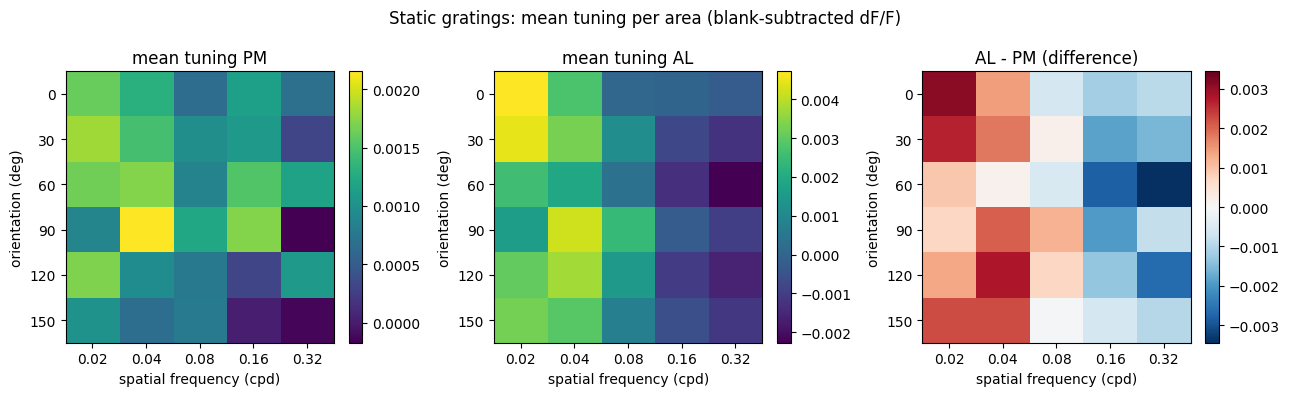

In [72]:
# --- Section 21a: mean static tuning per area (orientation x SF), and their difference ---
mean_pm = tuning_st[:, label_st == 0].mean(axis=1).reshape(n_ori, n_sf)
mean_al = tuning_st[:, label_st == 1].mean(axis=1).reshape(n_ori, n_sf)
diff    = mean_al - mean_pm

dmax = np.abs(diff).max()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, g, title, cmap, vlim in [
    (axes[0], mean_pm, "mean tuning PM", "viridis", (None, None)),
    (axes[1], mean_al, "mean tuning AL", "viridis", (None, None)),
    (axes[2], diff,    "AL - PM (difference)", "RdBu_r", (-dmax, dmax)),
]:
    im = ax.imshow(g, cmap=cmap, aspect="auto", vmin=vlim[0], vmax=vlim[1])
    ax.set_xticks(range(n_sf)); ax.set_xticklabels(sfvals_st)
    ax.set_yticks(range(n_ori)); ax.set_yticklabels(orivals_st.astype(int))
    ax.set_xlabel("spatial frequency (cpd)"); ax.set_ylabel("orientation (deg)")
    ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Static gratings: mean tuning per area (blank-subtracted dF/F)")
plt.tight_layout(); plt.show()

### 21b. Population tuning curves (SF and orientation)

Collapse each neuron's 30-vector to a **response-vs-SF** curve (average over orientations) and a **response-vs-orientation** curve (average over SFs), then average over all neurons of each area. Error bars are **SEM** (`std / sqrt(n)`), so we are comparing the two area means. The second cell turns the same curves into **preferred-feature distributions** (argmax per neuron) to compare PM vs AL as fractions.

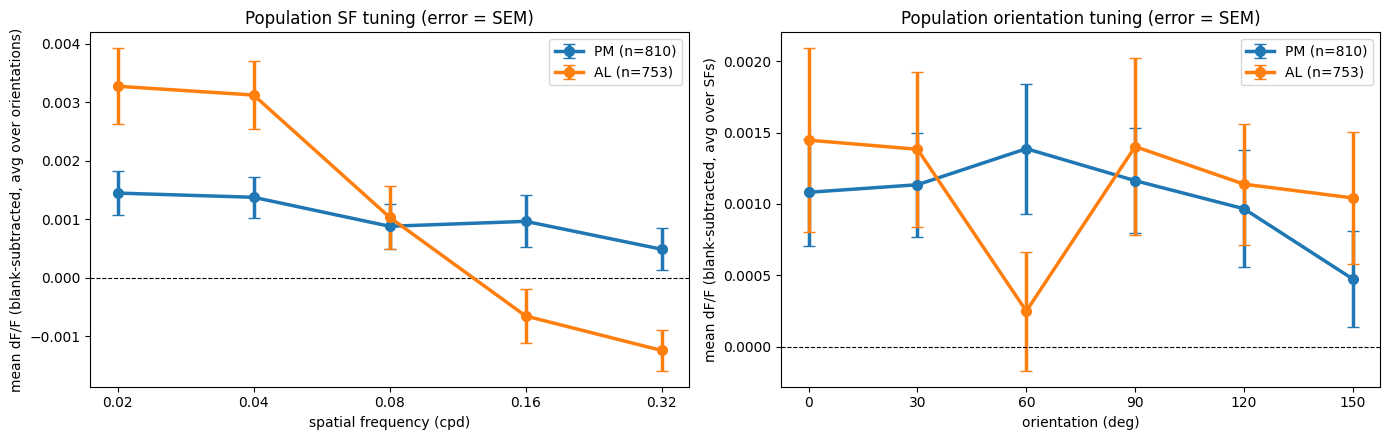

In [73]:
# --- Section 21b: population SF and orientation tuning curves (mean +/- SEM, PM vs AL) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# response vs spatial frequency (avg over orientations)
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    grp = sf_curves_st[label_st == lab]
    m   = grp.mean(axis=0); sem = grp.std(axis=0) / np.sqrt(len(grp))
    axes[0].errorbar(sfvals_st, m, yerr=sem, color=c, lw=2.5, marker="o", ms=7,
                     capsize=4, label=f"{name} (n={len(grp)})")
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_xscale("log", base=2)                     # SF is ~log-spaced
axes[0].set_xticks(sfvals_st); axes[0].set_xticklabels(sfvals_st)
axes[0].set_xlabel("spatial frequency (cpd)")
axes[0].set_ylabel("mean dF/F (blank-subtracted, avg over orientations)")
axes[0].set_title("Population SF tuning (error = SEM)"); axes[0].legend()

# response vs orientation (avg over SFs)
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    grp = ori_curves_st[label_st == lab]
    m   = grp.mean(axis=0); sem = grp.std(axis=0) / np.sqrt(len(grp))
    axes[1].errorbar(orivals_st, m, yerr=sem, color=c, lw=2.5, marker="o", ms=7,
                     capsize=4, label=f"{name} (n={len(grp)})")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xticks(orivals_st); axes[1].set_xticklabels(orivals_st.astype(int))
axes[1].set_xlabel("orientation (deg)")
axes[1].set_ylabel("mean dF/F (blank-subtracted, avg over SFs)")
axes[1].set_title("Population orientation tuning (error = SEM)"); axes[1].legend()

plt.tight_layout(); plt.show()

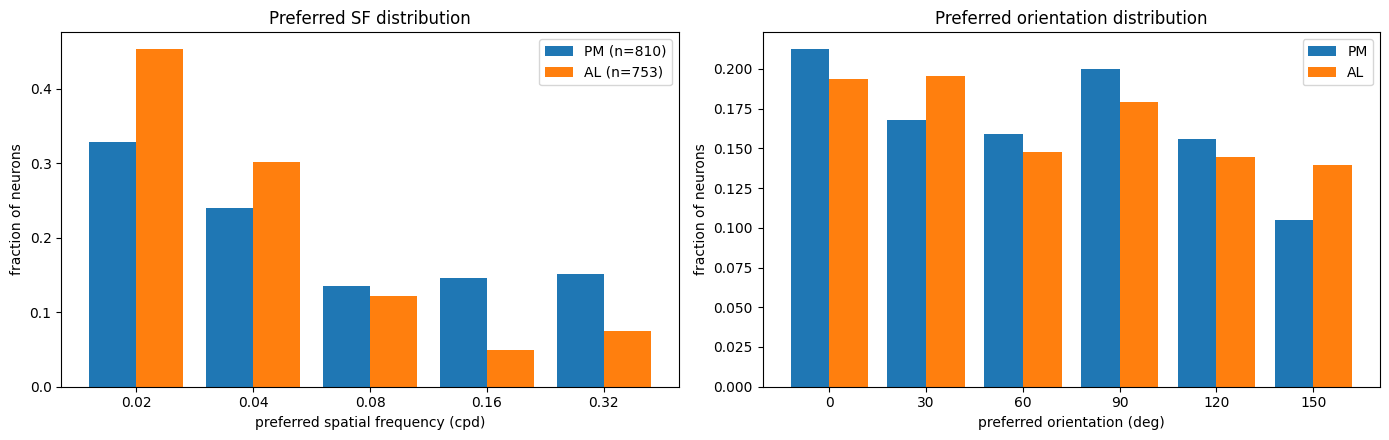

PM: median preferred SF = 0.040 cpd | fraction preferring high SF (>=0.16) = 0.30
AL: median preferred SF = 0.040 cpd | fraction preferring high SF (>=0.16) = 0.12


In [74]:
# --- Section 21b: preferred-feature distributions (argmax per neuron), PM vs AL as fractions ---
pref_sf  = sfvals_st[sf_curves_st.argmax(axis=1)]
pref_ori = orivals_st[ori_curves_st.argmax(axis=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# preferred SF distribution
x, w = np.arange(n_sf), 0.4
for k, (lab, name, c) in enumerate([(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]):
    vals = pref_sf[label_st == lab]
    frac = np.array([(vals == s).mean() for s in sfvals_st])
    axes[0].bar(x + (k - 0.5) * w, frac, width=w, color=c,
                label=f"{name} (n={int((label_st == lab).sum())})")
axes[0].set_xticks(x); axes[0].set_xticklabels(sfvals_st)
axes[0].set_xlabel("preferred spatial frequency (cpd)"); axes[0].set_ylabel("fraction of neurons")
axes[0].set_title("Preferred SF distribution"); axes[0].legend()

# preferred orientation distribution
xo, wo = np.arange(n_ori), 0.4
for k, (lab, name, c) in enumerate([(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]):
    vals = pref_ori[label_st == lab]
    frac = np.array([(vals == o).mean() for o in orivals_st])
    axes[1].bar(xo + (k - 0.5) * wo, frac, width=wo, color=c, label=name)
axes[1].set_xticks(xo); axes[1].set_xticklabels(orivals_st.astype(int))
axes[1].set_xlabel("preferred orientation (deg)"); axes[1].set_ylabel("fraction of neurons")
axes[1].set_title("Preferred orientation distribution"); axes[1].legend()

plt.tight_layout(); plt.show()

# compact numeric summary: is PM shifted toward high SF as the literature suggests?
hi_sf = 0.16                                          # "high SF" threshold (cpd)
for name, lab in [("PM", 0), ("AL", 1)]:
    v = pref_sf[label_st == lab]
    print(f"{name}: median preferred SF = {np.median(v):.3f} cpd | "
          f"fraction preferring high SF (>={hi_sf}) = {(v >= hi_sf).mean():.2f}")

### 21c. Look before you classify: PCA and t-SNE

Same model-free check as Section 5, on the 30-D static vectors: compress each neuron to 2D and colour by **area** (do PM/AL separate?) and by **session** (if points clump by session instead of area, that is a batch effect the grouped CV must guard against). Expect heavy overlap - single neurons are only weakly area-specific.

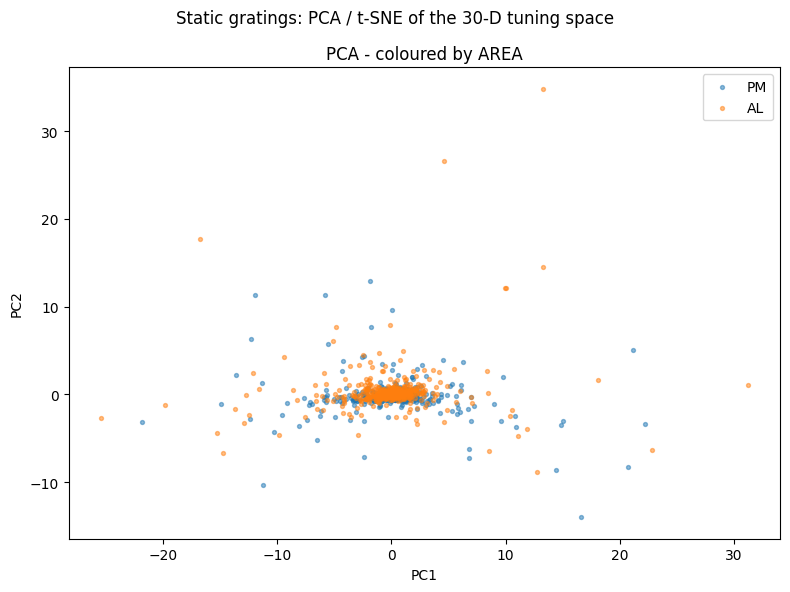

In [106]:
Xz_st = StandardScaler().fit_transform(tuning_st.T)      # one row per neuron, 30 standardized feats

pca_st  = PCA(n_components=2).fit_transform(Xz_st)
tsne_st = TSNE(n_components=2, random_state=0, init="pca").fit_transform(Xz_st)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# PCA coloured by area
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    m = label_st == lab
    axes.scatter(pca_st[m, 0], pca_st[m, 1], s=8, alpha=0.5, color=c, label=name)
axes.set_title("PCA - coloured by AREA"); axes.set_xlabel("PC1"); axes.set_ylabel("PC2"); axes.legend()
plt.suptitle("Static gratings: PCA / t-SNE of the 30-D tuning space")
plt.tight_layout(); plt.show()
# # PCA coloured by session (leakage check)
# for s in np.unique(groups_st):
#     m = groups_st == s
#     axes[1].scatter(pca_st[m, 0], pca_st[m, 1], s=8, alpha=0.5)
# axes[1].set_title("PCA - coloured by SESSION (leakage check)"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

# t-SNE coloured by area
# for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
#     m = label_st == lab
#     axes[1].scatter(tsne_st[m, 0], tsne_st[m, 1], s=8, alpha=0.5, color=c, label=name)
# axes[1].set_title("t-SNE - coloured by AREA"); axes[1].set_xlabel("dim 1"); axes[1].set_ylabel("dim 2"); axes[1].legend()

### 21d. Trial-level tuned neurons (SF / orientation) + PCA

Same advisor-driven idea as Section 19, now for static gratings: keep a neuron only if its response **changes a lot across a feature's levels** (relative change `depth = (R_max - R_min) / R_max`) **and** that change is **reliable across trials** (one-way ANOVA `p < alpha`). We read per-trial responses straight from `dff` (a static analog of `compute_tuning`) and compute both metrics for **spatial frequency** and **orientation**.

Both metrics are **label-agnostic** (never look at AL vs PM), so selecting on them before we look is denoising, not leakage. We then repeat the PCA on the 30-D space: all neurons vs SF-tuned-only vs orientation-tuned-only, to see whether removing untuned neurons separates the areas any better.

In [76]:
# --- Section 21d: trial-level tuned-neuron selection for static gratings ---
# Static analog of compute_tuning: per-trial mean dF/F + the stim table (orientation, spatial_frequency).
# Built in the SAME session order as build_static (Section 11) so masks align with label_st / groups_st.
from scipy.stats import f_oneway
import warnings

def compute_static_trials(session_id):
    data_set = boc.get_ophys_experiment_data(session_id)
    _, dff = data_set.get_dff_traces()
    ncells = dff.shape[0]
    stim = data_set.get_stimulus_table("static_gratings")
    starts = stim.start.values.astype(int); ends = stim.end.values.astype(int)
    resp = np.empty((len(stim), ncells))
    for t in range(len(stim)):
        resp[t] = dff[:, starts[t]:ends[t]].mean(axis=1)      # per-trial mean dF/F, all cells
    return stim, resp                                          # (n_trials, ncells)

def tuned_metrics_static(sid):
    stim, tr = compute_static_trials(sid)
    ori = stim.orientation.values; sf = stim.spatial_frequency.values
    def depth_and_p(colvals):
        levels = np.unique(colvals[np.isfinite(colvals)])     # drops blank/NaN trials
        blocks = [tr[colvals == lv] for lv in levels]         # trials grouped by level
        means  = np.vstack([b.mean(axis=0) for b in blocks])  # (n_levels, n_cells)
        mx, mn = means.max(axis=0), means.min(axis=0)
        depth  = np.where(mx > 0, (mx - mn) / mx, 0.0)        # relative change (the 25-50% idea)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                   # constant groups -> nan p
            p = f_oneway(*blocks).pvalue                       # reliability across trials
        return depth, np.nan_to_num(p, nan=1.0)
    d_sf,  p_sf  = depth_and_p(sf)
    d_ori, p_ori = depth_and_p(ori)
    return d_sf, p_sf, d_ori, p_ori

def build_tuned_static(exps):
    out = [tuned_metrics_static(s) for s in exps.id]
    return [np.concatenate(x) for x in zip(*out)]             # 4 arrays, each (n_cells_area,)

dsf_pm, psf_pm, dori_pm, pori_pm = build_tuned_static(exps_pm_st)
dsf_al, psf_al, dori_al, pori_al = build_tuned_static(exps_al_st)
depth_sf_st  = np.concatenate([dsf_pm,  dsf_al]);  p_sf_st  = np.concatenate([psf_pm,  psf_al])
depth_ori_st = np.concatenate([dori_pm, dori_al]); p_ori_st = np.concatenate([pori_pm, pori_al])

DEPTH_T, ALPHA = 0.25, 0.05                                   # >=25% relative change AND reliable
tuned_sf_st  = (depth_sf_st  >= DEPTH_T) & (p_sf_st  < ALPHA)
tuned_ori_st = (depth_ori_st >= DEPTH_T) & (p_ori_st < ALPHA)
for nm, mask in [("SF", tuned_sf_st), ("orientation", tuned_ori_st)]:
    print(f"{nm:11s}-tuned: {int(mask.sum()):4d}/{mask.size} neurons "
          f"(PM {int(mask[label_st==0].sum())}, AL {int(mask[label_st==1].sum())})")

SF         -tuned:  775/1563 neurons (PM 298, AL 477)
orientation-tuned:  504/1563 neurons (PM 228, AL 276)


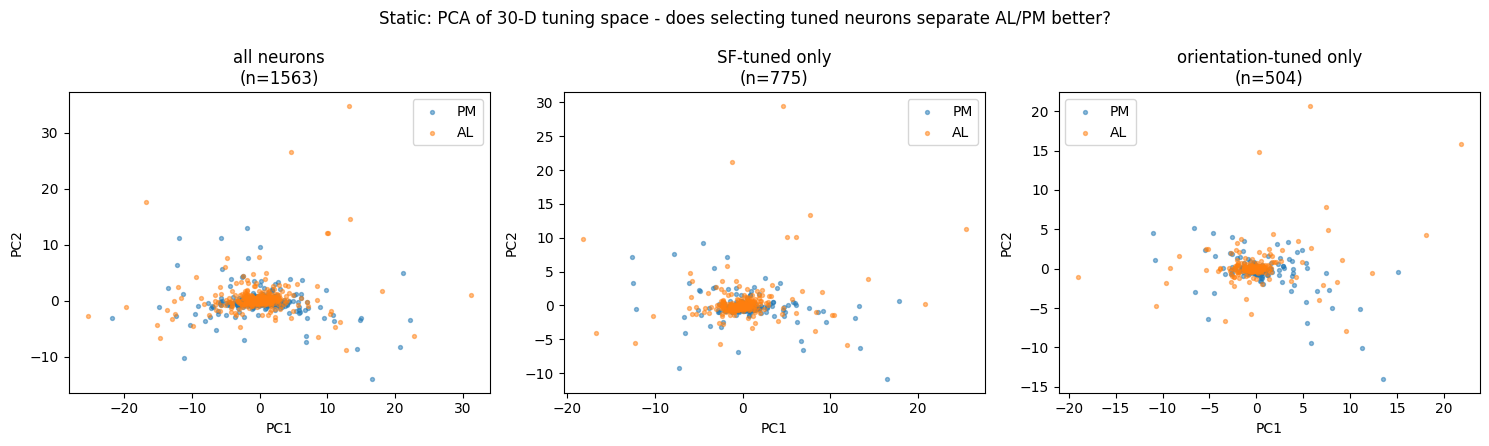

In [77]:
# --- Section 21d: PCA of the 30-D static space - all vs tuned-only, coloured by area ---
cols = {0: "tab:blue", 1: "tab:orange"}; nms = {0: "PM", 1: "AL"}

def pca_panel_st(ax, mask, title):
    if mask.sum() < 5:
        ax.set_title(title + "\n(too few)"); return
    Xz  = StandardScaler().fit_transform(tuning_st.T[mask])   # standardize the 30 features
    pcs = PCA(n_components=2).fit_transform(Xz)
    lab = label_st[mask]
    for cval in (0, 1):
        m = lab == cval
        ax.scatter(pcs[m, 0], pcs[m, 1], s=8, alpha=0.5, color=cols[cval], label=nms[cval])
    ax.set_title(f"{title}\n(n={int(mask.sum())})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()

all_mask = np.ones(len(label_st), bool)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pca_panel_st(axes[0], all_mask,     "all neurons")
pca_panel_st(axes[1], tuned_sf_st,  "SF-tuned only")
pca_panel_st(axes[2], tuned_ori_st, "orientation-tuned only")
plt.suptitle("Static: PCA of 30-D tuning space - does selecting tuned neurons separate AL/PM better?")
plt.tight_layout(); plt.show()

### 21e. Cross-validation decoding

Turn the pictures into numbers. Using the same session-grouped folds and three classifiers as Section 19b (LogReg + LDA linear, Random Forest nonlinear), we decode AL vs PM on: the **full 30** features, **SF-only** (5 feats), and **orientation-only** (6 feats) - each on **all neurons** and on the matched **tuned** subset from 21d. Selection stays label-agnostic and whole sessions are held out, so this is not leakage.

**Caveat:** the tuning thresholds (`DEPTH_T=0.25`, `ALPHA=0.05`) were fixed by hand; sweeping them and reporting the best would be the selection bias discussed in Sections 12/14/17.

full 30: all     n=1563 | bal 0.567 +/- 0.029
SF: all          n=1563 | bal 0.615 +/- 0.057
SF: SF-tuned     n= 775 | bal 0.587 +/- 0.037
ORI: all         n=1563 | bal 0.477 +/- 0.053
ORI: ori-tuned   n= 504 | bal 0.514 +/- 0.067


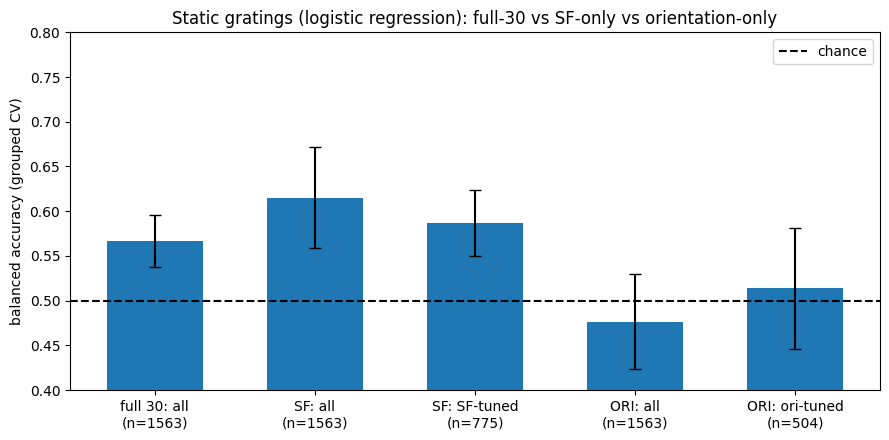


full-30 LogReg (here)        = 0.567
static 30-feat (Section 21.0) = 0.567 +/- 0.029


In [78]:
# --- Section 21e: grouped-CV decoding on static features - logistic regression only ---
def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

all_mask = np.ones(len(label_st), bool)
rows = [
    ("full 30: all",    tuning_st.T,   all_mask),
    ("SF: all",         sf_curves_st,  all_mask),
    ("SF: SF-tuned",    sf_curves_st,  tuned_sf_st),
    ("ORI: all",        ori_curves_st, all_mask),
    ("ORI: ori-tuned",  ori_curves_st, tuned_ori_st),
]

accs, errs, names = [], [], []
for name, X, mask in rows:
    gp, lp = groups_st[mask], label_st[mask]; ns = nsplits_for(lp, gp)
    names.append(f"{name}\n(n={int(mask.sum())})")
    if ns < 2 or mask.sum() < 10:
        accs.append(np.nan); errs.append(0.0)
        print(f"{name:16s} n={int(mask.sum()):4d} | skipped"); continue
    b, _ = grouped_cv_eval(X[mask], lp, gp, ns)               # logistic regression, session-grouped CV
    accs.append(b.mean()); errs.append(b.std())
    print(f"{name:16s} n={int(mask.sum()):4d} | bal {b.mean():.3f} +/- {b.std():.3f}")

x = np.arange(len(rows))
plt.figure(figsize=(9, 4.5))
plt.bar(x, accs, 0.6, yerr=errs, capsize=4, color="tab:blue")
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, names); plt.ylim(0.4, 0.8)
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Static gratings (logistic regression): full-30 vs SF-only vs orientation-only")
plt.legend(); plt.tight_layout(); plt.show()

# continuity check: the full-30 number here should match the 21.0 grouped-CV baseline
print(f"\nfull-30 LogReg (here)        = {accs[0]:.3f}")
print(f"static 30-feat (Section 21.0) = {bal_st.mean():.3f} +/- {bal_st.std():.3f}")

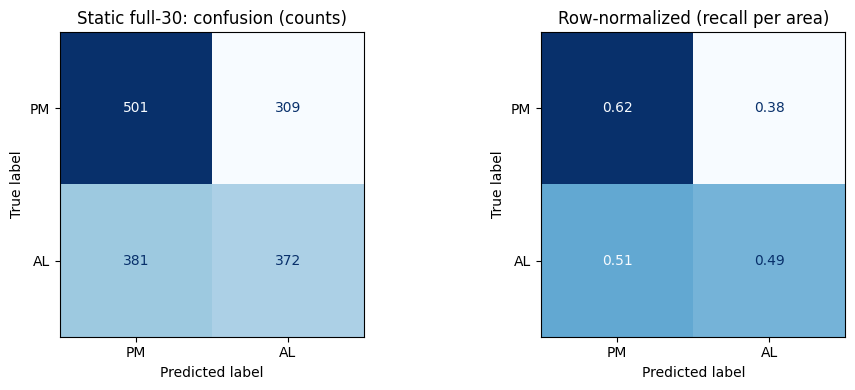

PM recall = 0.619 | AL recall = 0.494  (chance = 0.5)


In [79]:
# --- Section 21f: confusion matrix for the static full-30 logistic-regression decoder ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# pooled out-of-fold predictions from the same grouped-CV LogReg used in 21.0 / 21e
_, _, y_true, y_pred = grouped_cv_eval(X_static, label_st, groups_st, n_splits_st, return_preds=True)

cm = confusion_matrix(y_true, y_pred)                    # rows = true area, cols = predicted
cm_recall = cm / cm.sum(axis=1, keepdims=True)           # row-normalized -> per-area recall

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=["PM", "AL"]).plot(
    ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Static full-30: confusion (counts)")
ConfusionMatrixDisplay(cm_recall, display_labels=["PM", "AL"]).plot(
    ax=ax[1], colorbar=False, cmap="Blues", values_format=".2f")
ax[1].set_title("Row-normalized (recall per area)")
plt.tight_layout(); plt.show()

print(f"PM recall = {cm_recall[0, 0]:.3f} | AL recall = {cm_recall[1, 1]:.3f}  (chance = 0.5)")

### 21g. Static gratings: L2/3 vs L4 vs combined vs all depths

The static version of Section 13. We keep the same `Cux2-CreERT2` line but vary imaging depth: **L2/3 (175)** is the existing static dataset, **L4 (275)** is a new depth, **combined** stacks both, and **all depths** drops the depth filter entirely (every available depth). Each cohort is classified AL vs PM with **both** feature sets - the **full-30** tuning and **SF-only** (5 spatial frequencies, orientation averaged out) - under the same session-grouped CV, so the num-of-cells print is only a sanity line; the bars are the result.

Since static gratings have no temporal frequency, the interesting axis is **spatial frequency** (SF replaces TF here). Static recordings at 275 um may be scarce, so if an area has no L4 sessions we skip the L4 and combined cohorts (with a warning) rather than crash.

In [82]:
# --- Section 21g: static L4 (@275) + combined L2/3+L4 + all-depths datasets ---
# reuses compute_static_tuning / build_static and the L2/3 static set (tuning_st / label_st / groups_st) from 21.0
have_l4 = False
common_st_l4 = dict(cre_lines=['Cux2-CreERT2'], imaging_depths=[275], stimuli=['static_gratings'])
exps_pm_st_l4 = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_st_l4))
exps_al_st_l4 = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_st_l4))
print(f"static Cux2 L4 (@275) VISpm sessions: {len(exps_pm_st_l4)} | VISal sessions: {len(exps_al_st_l4)}")
if len(exps_pm_st_l4) > 0 and len(exps_al_st_l4) > 0:
    tuning_pm_st_l4, session_pm_st_l4 = build_static(exps_pm_st_l4)
    tuning_al_st_l4, session_al_st_l4 = build_static(exps_al_st_l4)
    label_st_l4  = np.append(np.repeat(0, tuning_pm_st_l4.shape[1]), np.repeat(1, tuning_al_st_l4.shape[1]))
    tuning_st_l4 = np.append(tuning_pm_st_l4, tuning_al_st_l4, axis=1)      # (30, n_L4)
    groups_st_l4 = np.concatenate([session_pm_st_l4, session_al_st_l4])
    # combined = existing L2/3 static + L4 static; session ids are distinct, so groups stays valid
    tuning_st_comb = np.append(tuning_st, tuning_st_l4, axis=1)
    label_st_comb  = np.append(label_st, label_st_l4)
    groups_st_comb = np.concatenate([groups_st, groups_st_l4])
    have_l4 = True
    print("static cells -> L2/3:", tuning_st.shape[1], "| L4:", tuning_st_l4.shape[1],
          "| combined:", tuning_st_comb.shape[1])
else:
    print("WARNING: no static L4 (@275) sessions for one area -> skipping L4 and combined cohorts.")

# all depths: SAME Cux2 line + static, but NO imaging_depths filter -> every available depth
# common_st_all = dict(cre_lines=['Cux2-CreERT2'], stimuli=['static_gratings'])
# exps_pm_st_all = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'], **common_st_all))
# exps_al_st_all = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'], **common_st_all))
# print(f"static Cux2 all-depths VISpm sessions: {len(exps_pm_st_all)} | VISal sessions: {len(exps_al_st_all)}"
#       f" | depths: {sorted(pd.concat([exps_pm_st_all, exps_al_st_all]).imaging_depth.unique())}")
# tuning_pm_st_all, session_pm_st_all = build_static(exps_pm_st_all)
# tuning_al_st_all, session_al_st_all = build_static(exps_al_st_all)
# label_st_all  = np.append(np.repeat(0, tuning_pm_st_all.shape[1]), np.repeat(1, tuning_al_st_all.shape[1]))
# tuning_st_all = np.append(tuning_pm_st_all, tuning_al_st_all, axis=1)       # (30, n_all_depths)
# groups_st_all = np.concatenate([session_pm_st_all, session_al_st_all])
# print("static all-depths cells:", tuning_st_all.shape[1])

static Cux2 L4 (@275) VISpm sessions: 4 | VISal sessions: 6
static cells -> L2/3: 1563 | L4: 1531 | combined: 3094


In [83]:
# --- Section 21g: full-30 vs SF-only across static cohorts (L2/3, L4, combined, all depths) ---
def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

cohorts = [("L2/3 (175)", tuning_st, label_st, groups_st)]
if have_l4:                                                     # only if static L4 sessions existed
    cohorts.append(("L4 (275)", tuning_st_l4,   label_st_l4,   groups_st_l4))
    cohorts.append(("L2/3+L4",  tuning_st_comb, label_st_comb, groups_st_comb))
cohorts.append(("all depths", tuning_st_all, label_st_all, groups_st_all))

res_full, err_full, res_sf, err_sf, names = [], [], [], [], []
for name, tun, lab, grp in cohorts:
    ns = nsplits_for(lab, grp)
    names.append(f"{name}\n(n={tun.shape[1]}; PM {int((lab == 0).sum())}, AL {int((lab == 1).sum())})")
    if ns < 2:
        res_full.append(np.nan); err_full.append(0); res_sf.append(np.nan); err_sf.append(0)
        print(f"{name}: skipped (n_splits<2)"); continue
    b30, _ = grouped_cv_eval(tun.T, lab, grp, ns)                                  # full 30 features
    bsf, _ = grouped_cv_eval(tun.T.reshape(-1, n_ori, n_sf).mean(axis=1), lab, grp, ns)  # SF-only (avg over orientations)
    res_full.append(b30.mean()); err_full.append(b30.std())
    res_sf.append(bsf.mean());   err_sf.append(bsf.std())
    print(f"{name}: n={tun.shape[1]:4d} | full30 {b30.mean():.3f}+/-{b30.std():.3f} | SF-only {bsf.mean():.3f}+/-{bsf.std():.3f}")

x, w = np.arange(len(cohorts)), 0.38
plt.figure(figsize=(9.5, 4.5))
plt.bar(x - w/2, res_full, w, yerr=err_full, capsize=4, label="full 30")
plt.bar(x + w/2, res_sf,   w, yerr=err_sf,   capsize=4, label="SF only (5)")
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, names); plt.ylim(0.4, 0.8)
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Static gratings: L2/3 vs L4 vs combined vs all depths"); plt.legend()
plt.tight_layout(); plt.show()

NameError: name 'tuning_st_all' is not defined

### 21h. All results in one chart: drifting vs static across layers

One figure pulling together every layer result from Section 13 (drifting) and Section 21g (static), for the **L2/3**, **L4**, and **combined** cohorts. Four bars per cohort: **drift full-40**, **drift TF-only**, **static full-30**, **static SF-only** (balanced accuracy, grouped CV, error = std).

Because Section 13 and 21g reuse the same result variables (`res_full` etc.), this cell **recomputes** both stimuli into separate variables so nothing is overwritten. Read it qualitatively: drifting and static come from different sessions/neurons and different feature dimensions (40 vs 30), so this compares the *area signal per stimulus*, not matched neurons.

L2/3 (175) | drift full 0.564 TF 0.592 | static full 0.567 SF 0.615
           drift n=1747 (PM 948, AL 799) | static n=1563 (PM 810, AL 753)
L4 (275)   | drift full 0.586 TF 0.667 | static full 0.511 SF 0.567
           drift n=1941 (PM 676, AL 1265) | static n=1531 (PM 522, AL 1009)


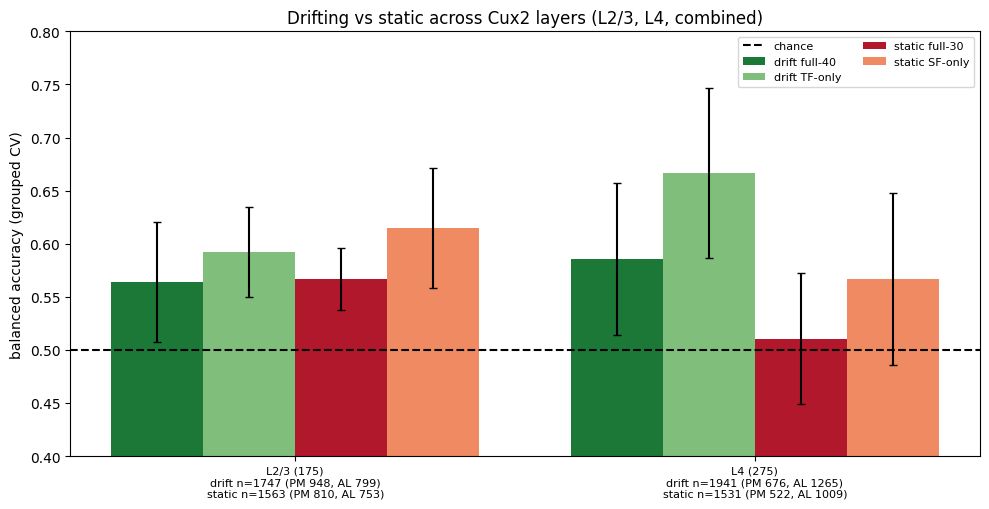

In [87]:
# --- Section 21h: combined drifting + static summary across L2/3, L4, combined ---
# Recompute both stimuli into distinct vars (Sec 13 / 21g reuse res_full etc., which would clobber).
def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

def eval_ff(tun, lab, grp, A, B):
    """(full_mean, full_std, feat_mean, feat_std): full = all features; feat = average out axis A -> B feats."""
    ns = nsplits_for(lab, grp)
    if ns < 2:
        return np.nan, 0.0, np.nan, 0.0
    bfull, _ = grouped_cv_eval(tun.T, lab, grp, ns)
    bfeat, _ = grouped_cv_eval(tun.T.reshape(-1, A, B).mean(axis=1), lab, grp, ns)
    return bfull.mean(), bfull.std(), bfeat.mean(), bfeat.std()

drift = {
    "L2/3 (175)": (tuning,      label,      groups),
    "L4 (275)":   (tuning_l4c,  label_l4c,  groups_l4c),
}
static = {"L2/3 (175)": (tuning_st, label_st, groups_st)}
if have_l4:                                                     # static L4 only if those sessions existed
    static["L4 (275)"] = (tuning_st_l4,   label_st_l4,   groups_st_l4)
    static["L2/3+L4"]  = (tuning_st_comb, label_st_comb, groups_st_comb)

order = ["L2/3 (175)", "L4 (275)"]
df_full, df_ferr, df_tf, df_tferr = [], [], [], []             # drift: full-40, TF-only
sf_full, sf_ferr, sf_sf, sf_sferr = [], [], [], []             # static: full-30, SF-only
names = []
for name in order:
    dfu, dfs, dtu, dts = eval_ff(*drift[name], 8, 5)           # drift: average out 8 directions -> 5 TF
    df_full.append(dfu); df_ferr.append(dfs); df_tf.append(dtu); df_tferr.append(dts)
    if name in static:
        sfu, sfs, ssu, sss = eval_ff(*static[name], n_ori, n_sf)   # static: average out orientation -> SF
    else:
        sfu, sfs, ssu, sss = np.nan, 0.0, np.nan, 0.0
    sf_full.append(sfu); sf_ferr.append(sfs); sf_sf.append(ssu); sf_sferr.append(sss)
    # neuron counts per stimulus (PM / AL) for the x-axis label
    ld = drift[name][1]
    d_txt = f"drift n={len(ld)} (PM {int((ld == 0).sum())}, AL {int((ld == 1).sum())})"
    if name in static:
        ls = static[name][1]
        s_txt = f"static n={len(ls)} (PM {int((ls == 0).sum())}, AL {int((ls == 1).sum())})"
    else:
        s_txt = "static n=0"
    names.append(f"{name}\n{d_txt}\n{s_txt}")
    print(f"{name:10s} | drift full {dfu:.3f} TF {dtu:.3f} | "
          f"static full {sfu if np.isfinite(sfu) else float('nan'):.3f} SF {ssu if np.isfinite(ssu) else float('nan'):.3f}")
    print(f"           {d_txt} | {s_txt}")

x, w = np.arange(len(order)), 0.2
series = [
    ("drift full-40",  df_full, df_ferr,  "#1b7837"),          # dark green  (drifting)
    ("drift TF-only",  df_tf,   df_tferr, "#7fbf7b"),          # light green (drifting)
    ("static full-30", sf_full, sf_ferr,  "#b2182b"),          # dark red    (static)
    ("static SF-only", sf_sf,   sf_sferr, "#ef8a62"),          # light red   (static)
]

plt.figure(figsize=(10, 5.2))
for i, (lab_i, vals, errs, col) in enumerate(series):
    plt.bar(x + (i - 1.5) * w, vals, w, yerr=errs, capsize=3, color=col, label=lab_i)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.xticks(x, names, fontsize=8); plt.ylim(0.4, 0.8)qs
plt.ylabel("balanced accuracy (grouped CV)")
plt.title("Drifting vs static across Cux2 layers (L2/3, L4, combined)")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

Number of cells:  231
Number of cells:  85
Number of cells:  128
Number of cells:  232
Number of cells:  240
Number of cells:  202
Number of cells:  162
Number of cells:  168
Number of cells:  207
Number of cells:  286
drift  L4 TF-tuned :  891/1941 (PM 277, AL 614)
static L4 SF-tuned :  684/1531 (PM 163, AL 521)
Drifti L2/3 (175) | full-40 0.569 | TF-only (5) 0.618 | tuned n=860
Drifti L4 (275)   | full-40 0.619 | TF-only (5) 0.691 | tuned n=891


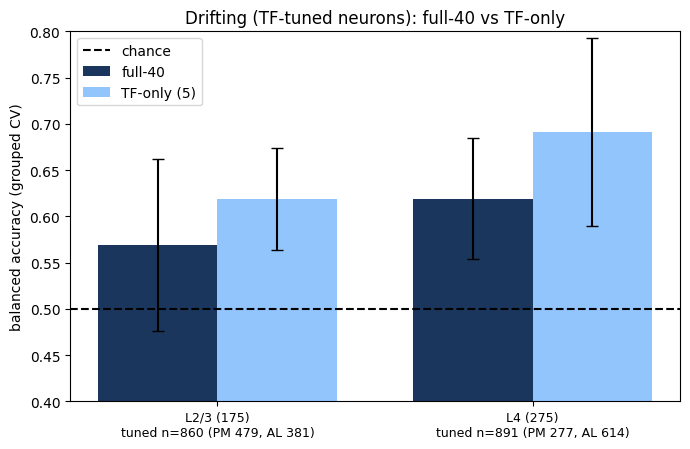

Static L2/3 (175) | full-30 0.579 | SF-only (5) 0.587 | tuned n=775
Static L4 (275)   | full-30 0.480 | SF-only (5) 0.604 | tuned n=684


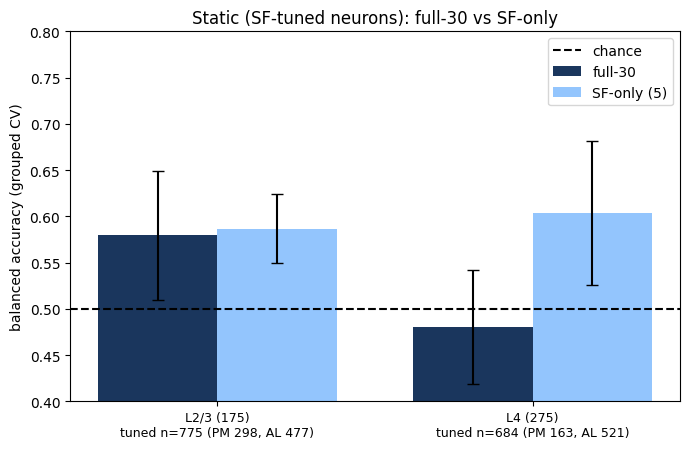

In [99]:
# --- Section 21h: tuned-neuron layer comparison, one figure per stimulus ---
def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

# L4 tuned masks (L2/3 already has tuned_tf / tuned_sf_st from Sections 19 / 21d)
d_pm, p_pm, _, _ = build_tuned(exps_pm_l4c)                     # drift L4, aligned to label_l4c
d_al, p_al, _, _ = build_tuned(exps_al_l4c)
tuned_tf_l4 = (np.concatenate([d_pm, d_al]) >= DEPTH_T) & (np.concatenate([p_pm, p_al]) < ALPHA)
print(f"drift  L4 TF-tuned : {int(tuned_tf_l4.sum()):4d}/{tuned_tf_l4.size} "
      f"(PM {int(tuned_tf_l4[label_l4c==0].sum())}, AL {int(tuned_tf_l4[label_l4c==1].sum())})")

if have_l4:                                                     # static L4 only if those sessions existed
    d_pm, p_pm, _, _ = build_tuned_static(exps_pm_st_l4)        # static L4, aligned to label_st_l4
    d_al, p_al, _, _ = build_tuned_static(exps_al_st_l4)
    tuned_sf_l4 = (np.concatenate([d_pm, d_al]) >= DEPTH_T) & (np.concatenate([p_pm, p_al]) < ALPHA)
    print(f"static L4 SF-tuned : {int(tuned_sf_l4.sum()):4d}/{tuned_sf_l4.size} "
          f"(PM {int(tuned_sf_l4[label_st_l4==0].sum())}, AL {int(tuned_sf_l4[label_st_l4==1].sum())})")

def eval_tuned(tun, lab, grp, mask, A, B):
    """(full_mean, full_std, feat_mean, feat_std) on the TUNED subset: full = all features; feat = avg out axis A."""
    lp, gp = lab[mask], grp[mask]; ns = nsplits_for(lp, gp)
    if ns < 2 or mask.sum() < 10:
        return np.nan, 0.0, np.nan, 0.0
    X = tun.T[mask]                                             # tuned neurons, all features
    bfull, _ = grouped_cv_eval(X, lp, gp, ns)
    bfeat, _ = grouped_cv_eval(X.reshape(-1, A, B).mean(axis=1), lp, gp, ns)
    return bfull.mean(), bfull.std(), bfeat.mean(), bfeat.std()

def tuned_layer_fig(cohorts, A, B, full_lab, feat_lab, colors, title):
    """Grouped bars over layers: full-feature and feature-only, both on the tuned subset."""
    full_m, full_e, feat_m, feat_e, names = [], [], [], [], []
    for name, tun, lab, grp, mask in cohorts:
        fu, fe, cu, ce = eval_tuned(tun, lab, grp, mask, A, B)
        full_m.append(fu); full_e.append(fe); feat_m.append(cu); feat_e.append(ce)
        names.append(f"{name}\ntuned n={int(mask.sum())} "
                     f"(PM {int((lab[mask]==0).sum())}, AL {int((lab[mask]==1).sum())})")
        print(f"{title[:6]} {name:10s} | {full_lab} {fu:.3f} | {feat_lab} {cu:.3f} "
              f"| tuned n={int(mask.sum())}")
    x, w = np.arange(len(cohorts)), 0.38
    plt.figure(figsize=(7, 4.6))
    plt.bar(x - w / 2, full_m, w, yerr=full_e, capsize=4, color=colors[0], label=full_lab)
    plt.bar(x + w / 2, feat_m, w, yerr=feat_e, capsize=4, color=colors[1], label=feat_lab)
    plt.axhline(0.5, ls="--", color="k", label="chance")
    plt.xticks(x, names, fontsize=9); plt.ylim(0.4, 0.8)
    plt.ylabel("balanced accuracy (grouped CV)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# --- Figure 1: drifting (TF-tuned neurons) ---
drift_cohorts = [
    ("L2/3 (175)", tuning,     label,     groups,     tuned_tf),
    ("L4 (275)",   tuning_l4c, label_l4c, groups_l4c, tuned_tf_l4),
]
tuned_layer_fig(drift_cohorts, 8, 5, "full-40", "TF-only (5)",
                ["#1A365D", "#93C5FD"], "Drifting (TF-tuned neurons): full-40 vs TF-only")
#003f5c
#58508d
# --- Figure 2: static (SF-tuned neurons) ---
static_cohorts = [("L2/3 (175)", tuning_st, label_st, groups_st, tuned_sf_st)]
if have_l4:
    static_cohorts.append(("L4 (275)", tuning_st_l4, label_st_l4, groups_st_l4, tuned_sf_l4))
tuned_layer_fig(static_cohorts, n_ori, n_sf, "full-30", "SF-only (5)",
                ["#1A365D", "#93C5FD"], "Static (SF-tuned neurons): full-30 vs SF-only")

## 23. Temporal 1D-CNN across layers (drifting + static)

Every decoder so far used the **trial-averaged tuning vector** - time within a trial was thrown away. Here we keep it. For each neuron and each stimulus condition we build the trial-averaged dF/F **time course** `(T, C)`: `T` = frames after stimulus onset, `C` = the conditions treated as channels (40 = 8 directions x 5 TF for drifting, 30 = 6 orientations x 5 SF for static). A small **1D-CNN** convolves across time and learns from the within-trial dynamics.

This mirrors the **Section 21h** chart - same Cux2 cohorts (L2/3, L4, combined), same `balanced_group_folds`, same "full" vs "feature-only" split - but swaps logistic regression for the CNN. "Feature-only" collapses the channel axis (drift: average the 8 directions -> 5 TF channels; static: average the orientations -> 5 SF channels), keeping time.

Notes: this is the **slowest** section (it re-reads `dff` for every drifting and static session, then trains ~3 cohorts x 4 tasks x folds tiny nets). It **requires TensorFlow** and is fully guarded by `TF_OK`, so the notebook still runs without it. Config knobs (`T_DRIFT`, `T_STATIC`, `EPOCHS`, `SEED`, `SUBSAMPLE`) sit at the top of the cells. If the nets don't beat the ~0.5-0.6 LogReg numbers, the mean tuning already captured the area signal.

In [106]:
# --- Section 23: build the response-over-time tensors (n_cells, T, C) ---
# SLOW: re-reads dff for every session. Sessions are visited in the SAME order as
# build_area / build_static (PM sessions then AL), so rows line up with label*/groups*.
T_DRIFT  = 30   # frames after onset for drifting gratings (~1 s at 30 Hz)
T_STATIC = 7    # frames after onset for static gratings (~0.25 s presentation)

def get_timeseries_drift(session_id, T=T_DRIFT):
    """Trial-averaged dF/F time course per neuron -> (n_cells, T, 40).
    Channel c = j_ori*len(tfvals)+i_tf, matching the 40-vector (ori-major) order."""
    data_set = boc.get_ophys_experiment_data(int(session_id))
    _, dff = data_set.get_dff_traces()
    n_cells = dff.shape[0]
    stim = data_set.get_stimulus_table('drifting_gratings')
    orivals = np.unique(stim.orientation.values); orivals = orivals[np.isfinite(orivals)]
    tfvals  = np.unique(stim.temporal_frequency.values); tfvals = tfvals[np.isfinite(tfvals)]
    n_cond = len(orivals) * len(tfvals)
    resp   = np.zeros((n_cells, T, n_cond)); counts = np.zeros(n_cond)
    for _, row in stim.iterrows():
        if not np.isfinite(row.orientation):                 # skip blank sweeps
            continue
        j = int(np.where(orivals == row.orientation)[0][0])
        i = int(np.where(tfvals == row.temporal_frequency)[0][0])
        c = j * len(tfvals) + i
        s = int(row.start); seg = dff[:, s:s + T]
        if seg.shape[1] < T:                                 # pad short trials
            seg = np.pad(seg, ((0, 0), (0, T - seg.shape[1])), mode='edge')
        resp[:, :, c] += seg; counts[c] += 1
    resp /= np.maximum(counts, 1)[None, None, :]
    return resp

def get_timeseries_static(session_id, T=T_STATIC):
    """Trial-averaged dF/F time course per neuron -> (n_cells, T, 30).
    Channel c = j_ori*len(sfvals)+i_sf (ori-major), matching compute_static_tuning."""
    data_set = boc.get_ophys_experiment_data(int(session_id))
    _, dff = data_set.get_dff_traces()
    n_cells = dff.shape[0]
    stim = data_set.get_stimulus_table('static_gratings')
    orivals = np.unique(stim.orientation.values); orivals = orivals[np.isfinite(orivals)]
    sfvals  = np.unique(stim.spatial_frequency.values); sfvals = sfvals[np.isfinite(sfvals)]
    n_cond = len(orivals) * len(sfvals)
    resp   = np.zeros((n_cells, T, n_cond)); counts = np.zeros(n_cond)
    for _, row in stim.iterrows():
        if not (np.isfinite(row.orientation) and np.isfinite(row.spatial_frequency)):
            continue                                         # skip blank sweeps
        j = int(np.where(orivals == row.orientation)[0][0])
        i = int(np.where(sfvals == row.spatial_frequency)[0][0])
        c = j * len(sfvals) + i                              # averages over the 4 phases via trial mean
        s = int(row.start); seg = dff[:, s:s + T]
        if seg.shape[1] < T:
            seg = np.pad(seg, ((0, 0), (0, T - seg.shape[1])), mode='edge')
        resp[:, :, c] += seg; counts[c] += 1
    resp /= np.maximum(counts, 1)[None, None, :]
    return resp

def stack_sessions(ids, fn, T):
    """Concatenate per-session (n_cells, T, C) tensors along the neuron axis, in order."""
    parts = []
    for sid in ids:
        print("  timeseries for session", sid)
        parts.append(fn(sid, T))
    return np.concatenate(parts, axis=0)

# --- drifting cohorts (same session order as build_area) ---
print("drift L2/3:")
resp_drift_l23 = stack_sessions(list(exps_pm.id) + list(exps_al.id), get_timeseries_drift, T_DRIFT)
assert resp_drift_l23.shape[0] == len(label), "resp_drift_l23 misaligned with label"
print("drift L4:")
resp_drift_l4  = stack_sessions(list(exps_pm_l4c.id) + list(exps_al_l4c.id), get_timeseries_drift, T_DRIFT)
assert resp_drift_l4.shape[0] == len(label_l4c), "resp_drift_l4 misaligned with label_l4c"
resp_drift_comb = np.concatenate([resp_drift_l23, resp_drift_l4], axis=0)   # matches label_comb/groups_comb
assert resp_drift_comb.shape[0] == len(label_comb), "resp_drift_comb misaligned with label_comb"

# --- static cohorts (same session order as build_static) ---
print("static L2/3:")
resp_static_l23 = stack_sessions(list(exps_pm_st.id) + list(exps_al_st.id), get_timeseries_static, T_STATIC)
assert resp_static_l23.shape[0] == len(label_st), "resp_static_l23 misaligned with label_st"
if have_l4:
    print("static L4:")
    resp_static_l4 = stack_sessions(list(exps_pm_st_l4.id) + list(exps_al_st_l4.id), get_timeseries_static, T_STATIC)
    assert resp_static_l4.shape[0] == len(label_st_l4), "resp_static_l4 misaligned with label_st_l4"
    resp_static_comb = np.concatenate([resp_static_l23, resp_static_l4], axis=0)
    assert resp_static_comb.shape[0] == len(label_st_comb), "resp_static_comb misaligned with label_st_comb"

print("\ndrift  tensors:", resp_drift_l23.shape, resp_drift_l4.shape, resp_drift_comb.shape)
print("static tensors:", resp_static_l23.shape, ("(L4/comb present)" if have_l4 else "(L2/3 only)"))

drift L2/3:
  timeseries for session 504115289
  timeseries for session 502666254
  timeseries for session 658854537
  timeseries for session 512311673
  timeseries for session 510859641
  timeseries for session 503324629
  timeseries for session 657914280
  timeseries for session 502376461
  timeseries for session 506773185
  timeseries for session 506773892
  timeseries for session 557225279
  timeseries for session 503412730
  timeseries for session 502199136
  timeseries for session 501876401
  timeseries for session 501933264
drift L4:
  timeseries for session 507691036
  timeseries for session 716956096
  timeseries for session 663866413
  timeseries for session 505845219
  timeseries for session 512326618
  timeseries for session 505407318
  timeseries for session 627823344
  timeseries for session 558670888
  timeseries for session 507464107
  timeseries for session 512164988
static L2/3:
  timeseries for session 503772253
  timeseries for session 659749630
  timeseries for ses

L2/3 (175) | CNN  drift full 0.604 TF 0.631 | static full 0.652 SF 0.662
           | LogReg ref      drift full 0.564 TF 0.592 | static full 0.567 SF 0.615
L4 (275)   | CNN  drift full 0.603 TF 0.536 | static full 0.558 SF 0.558
           | LogReg ref      drift full 0.586 TF 0.667 | static full 0.511 SF 0.567
L2/3+L4    | CNN  drift full 0.653 TF 0.676 | static full 0.655 SF 0.664
           | LogReg ref      drift full 0.562 TF 0.606 | static full 0.625 SF 0.647


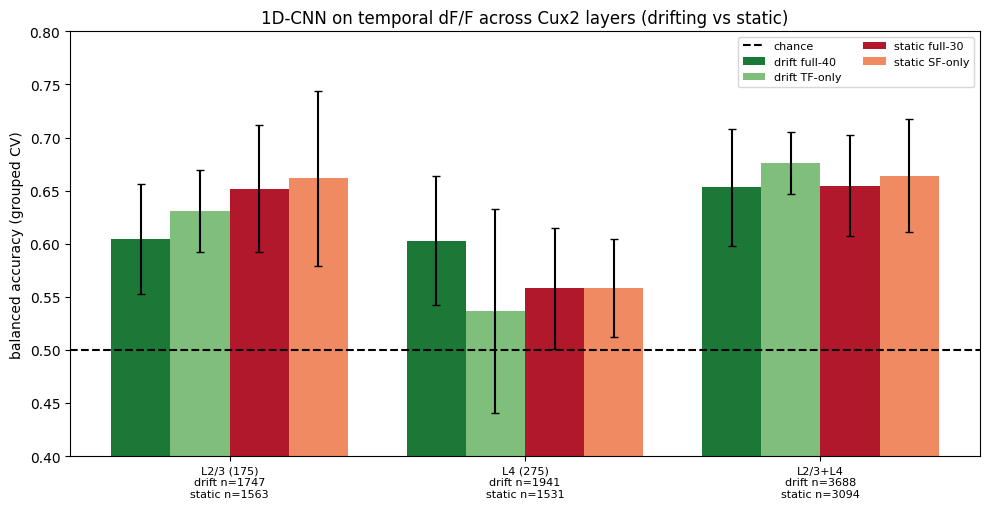

In [107]:
# --- Section 23: 1D-CNN on the temporal tensors, mirroring the 21h chart ---
EPOCHS, SEED, SUBSAMPLE = 50, 0, 1.0    # SUBSAMPLE<1.0 = random fraction of neurons (per cohort) to go faster
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

try:
    import tensorflow as tf
    from tensorflow.keras import layers, Sequential
    from tensorflow.keras.callbacks import EarlyStopping
    TF_OK = True
except Exception as e:
    TF_OK = False
    print("TensorFlow not available - skip Section 23 (pip install tensorflow):", e)

def nsplits_for(lp, gp):
    return min(5, len(np.unique(gp[lp == 0])), len(np.unique(gp[lp == 1])))

def chan_collapse(resp, A, B):
    """(n, T, A*B) -> (n, T, B): average out the first stimulus axis (directions / orientations)."""
    n, T, _ = resp.shape
    return resp.reshape(n, T, A, B).mean(axis=2)

def build_cnn(T, C):
    m = Sequential([
        layers.Input((T, C)),
        layers.Conv1D(16, 3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy")
    return m

def run_temporal_cnn(resp, y, groups, ns, epochs=EPOCHS, seed=SEED):
    """Tiny 1D-CNN under the SAME balanced session folds. z-scores with train-fold
    stats, early-stops on an inner slice, returns per-fold balanced accuracy."""
    y = np.asarray(y)
    fold = balanced_group_folds(y, groups, ns, seed)
    bals = []
    for k in range(ns):
        tr, va = fold != k, fold == k
        if len(np.unique(y[va])) < 2 or len(np.unique(y[tr])) < 2:
            continue
        mu = resp[tr].mean(axis=(0, 1), keepdims=True)
        sd = resp[tr].std(axis=(0, 1), keepdims=True) + 1e-9
        Xtr, Xva = (resp[tr] - mu) / sd, (resp[va] - mu) / sd
        ytr = y[tr]
        itr, iva = train_test_split(np.arange(len(ytr)), test_size=0.2,
                                    stratify=ytr, random_state=seed)
        tf.keras.utils.set_random_seed(seed)
        model = build_cnn(resp.shape[1], resp.shape[2])
        es = EarlyStopping(patience=8, restore_best_weights=True)
        model.fit(Xtr[itr], ytr[itr], validation_data=(Xtr[iva], ytr[iva]),
                  epochs=epochs, batch_size=32, verbose=0, callbacks=[es])
        p = model.predict(Xva, verbose=0).ravel()
        bals.append(balanced_accuracy_score(y[va], (p >= 0.5).astype(int)))
    return np.array(bals) if bals else np.array([np.nan])

def logreg_ref(tun, lab, grp, A, B):
    """LogReg balanced acc for (full, feature-only) as a reference next to the CNN."""
    ns = nsplits_for(lab, grp)
    if ns < 2:
        return np.nan, np.nan
    bf, _ = grouped_cv_eval(tun.T, lab, grp, ns)
    bc, _ = grouped_cv_eval(tun.T.reshape(-1, A, B).mean(axis=1), lab, grp, ns)
    return bf.mean(), bc.mean()

if TF_OK:
    drift_map = {
        "L2/3 (175)": (resp_drift_l23,  tuning,      label,      groups),
        "L4 (275)":   (resp_drift_l4,   tuning_l4c,  label_l4c,  groups_l4c),
        "L2/3+L4":    (resp_drift_comb, tuning_comb, label_comb, groups_comb),
    }
    static_map = {"L2/3 (175)": (resp_static_l23, tuning_st, label_st, groups_st)}
    if have_l4:
        static_map["L4 (275)"] = (resp_static_l4,   tuning_st_l4,   label_st_l4,   groups_st_l4)
        static_map["L2/3+L4"]  = (resp_static_comb, tuning_st_comb, label_st_comb, groups_st_comb)

    order = ["L2/3 (175)", "L4 (275)", "L2/3+L4"]
    df_full, df_tf, sf_full, sf_sf, names = [], [], [], [], []
    rng = np.random.default_rng(SEED)

    def cnn_pair(resp, y, g, A, B):
        """(full C-channel, feature-only B-channel) CNN balanced acc, with optional subsample."""
        y = np.asarray(y); g = np.asarray(g)
        if SUBSAMPLE < 1.0:                                   # subsample resp/y/g together (keeps alignment)
            idx = rng.choice(len(y), int(len(y) * SUBSAMPLE), replace=False)
            resp, y, g = resp[idx], y[idx], g[idx]
        ns = nsplits_for(y, g)
        if ns < 2 or len(y) < 10:
            return np.nan, 0.0, np.nan, 0.0
        bf = run_temporal_cnn(resp, y, g, ns)
        bc = run_temporal_cnn(chan_collapse(resp, A, B), y, g, ns)
        return np.nanmean(bf), np.nanstd(bf), np.nanmean(bc), np.nanstd(bc)

    df_ferr, df_tferr, sf_ferr, sf_sferr = [], [], [], []
    for name in order:
        rd, td, yd, gd = drift_map[name]
        dfu, dfe, dtu, dte = cnn_pair(rd, yd, gd, 8, 5)       # drift: collapse 8 directions -> 5 TF
        df_full.append(dfu); df_ferr.append(dfe); df_tf.append(dtu); df_tferr.append(dte)
        lr_df, lr_dt = logreg_ref(td, yd, gd, 8, 5)

        if name in static_map:
            rs, ts, ys, gs = static_map[name]
            sfu, sfe, ssu, sse = cnn_pair(rs, ys, gs, n_ori, n_sf)   # static: collapse orientation -> SF
            lr_sf, lr_ss = logreg_ref(ts, ys, gs, n_ori, n_sf)
            s_n = f"static n={len(ys)}"
        else:
            sfu, sfe, ssu, sse = np.nan, 0.0, np.nan, 0.0
            lr_sf, lr_ss, s_n = np.nan, np.nan, "static n=0"
        sf_full.append(sfu); sf_ferr.append(sfe); sf_sf.append(ssu); sf_sferr.append(sse)

        names.append(f"{name}\ndrift n={len(yd)}\n{s_n}")
        print(f"{name:10s} | CNN  drift full {dfu:.3f} TF {dtu:.3f} | static full {sfu:.3f} SF {ssu:.3f}")
        print(f"           | LogReg ref      drift full {lr_df:.3f} TF {lr_dt:.3f} | static full {lr_sf:.3f} SF {lr_ss:.3f}")

    x, w = np.arange(len(order)), 0.2
    series = [
        ("drift full-40",  df_full, df_ferr,  "#1b7837"),     # dark green  (drifting)
        ("drift TF-only",  df_tf,   df_tferr, "#7fbf7b"),     # light green (drifting)
        ("static full-30", sf_full, sf_ferr,  "#b2182b"),     # dark red    (static)
        ("static SF-only", sf_sf,   sf_sferr, "#ef8a62"),     # light red   (static)
    ]
    plt.figure(figsize=(10, 5.2))
    for i, (lab_i, vals, errs, col) in enumerate(series):
        plt.bar(x + (i - 1.5) * w, vals, w, yerr=errs, capsize=3, color=col, label=lab_i)
    plt.axhline(0.5, ls="--", color="k", label="chance")
    plt.xticks(x, names, fontsize=8); plt.ylim(0.4, 0.8)
    plt.ylabel("balanced accuracy (grouped CV)")
    plt.title("1D-CNN on temporal dF/F across Cux2 layers (drifting vs static)")
    plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

Other directions you can take this project in:


1.   If you've found some success in predicting AL and PM, see if you can compare other brain regions. Are there brain regions that are easier to differentiate than others?
2.   Here we used the tuning array for the response to drifting gratings to predict brain region. Could you use other aspects of the neurons' responses? For example, try using the dff traces during the spontaneous activity or the natural movie response. What other types of features could you look at?

